## Gene analysis for fig 1

In [1]:
import pandas as pd
import glob
import re

data_dir = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

dfs = []
for f in glob.glob(f'{data_dir}/censat_regions_pass_qc_chr*.tsv'):
    chrom = re.search(r'chr[\dXYM]+', f).group(0)
    df = pd.read_csv(f, sep='\t')
    df['chrom'] = chrom
    dfs.append(df)

censat_df = pd.concat(dfs, ignore_index=True)
print(censat_df.shape)
censat_df.head()


(4153, 26)


,sample_id,haplotype,assembly_id,sequence_id,region_start,region_end,region_size_bp,feature_count,region_label_bp_json,simplified_label_bp_json,...,contig_size,dist_to_contig_start,dist_to_contig_end,region_not_near_contig_edge,reference_large_array_labels_json,all_large_arrays_represented,sequences_per_assembly_chrom,single_sequence_for_chrom,pass_qc,chrom
0,CHM13,0,chm13v2.0_maskedY_rCRS,CHM13#0#chr18,14298107,21125235,6827128,33,"{""active_hor(S2C18H1L)"": 4967510, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6819, ""active"": 496751...",...,80542538.0,14298107,59417303.0,True,"[""active""]",True,1.0,True,True,chr18
1,HG00097,1,HG00097_hap1_hprc_r2_v1.0.1,HG00097#1#JBIRDD010000010.1,14135694,19270914,5135220,40,"{""active_hor(S2C18H1L)"": 3113600, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 311360...",...,78710895.0,14135694,59439981.0,True,"[""active""]",True,1.0,True,True,chr18
2,HG00097,2,HG00097_hap2_hprc_r2_v1.0.1,HG00097#2#CM094084.1,14138081,20853464,6715383,33,"{""active_hor(S2C18H1L)"": 4697016, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 469701...",...,80317024.0,14138081,59463560.0,True,"[""active""]",True,1.0,True,True,chr18
3,HG00099,1,HG00099_hap1_hprc_r2_v1.0.1,HG00099#1#CM087325.1,14150536,20957234,6806698,37,"{""active_hor(S2C18H1L)"": 4765242, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 476524...",...,80476601.0,14150536,59519367.0,True,"[""active""]",True,1.0,True,True,chr18
4,HG00099,2,HG00099_hap2_hprc_r2_v1.0.1,HG00099#2#CM087369.1,14095274,20715119,6619845,37,"{""active_hor(S2C18H1L)"": 4536062, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 453606...",...,80141396.0,14095274,59426277.0,True,"[""active""]",True,1.0,True,True,chr18


In [ ]:
print(censat_df.columns.tolist())


['sample_id', 'haplotype', 'assembly_id', 'sequence_id', 'region_start', 'region_end', 'region_size_bp', 'feature_count', 'region_label_bp_json', 'simplified_label_bp_json', 'contains_active_array', 'observed_large_array_count', 'observed_large_array_labels_json', 'has_multi_source_qc_flag', 'chrom_assignment', 'level', 'contig_size', 'dist_to_contig_start', 'dist_to_contig_end', 'region_not_near_contig_edge', 'reference_large_array_labels_json', 'all_large_arrays_represented', 'sequences_per_assembly_chrom', 'single_sequence_for_chrom', 'pass_qc', 'chrom']


In [ ]:
cat_index=/private/home/juklucas/github/censat_paper/data_tables/annotation/genes/cat_genes_hprc_r2_v1.3.index.csv

SyntaxError: invalid syntax (783702810.py, line 1)

### Create bed files of censat regions for all samples 

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import glob

CENSAT_DIR   = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'
CAT_GENE_IDX = '/private/home/juklucas/github/censat_paper/data_tables/annotation/genes/cat_genes_hprc_r2_v1.3.index.csv'

outdir = Path(f'/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out')
bed_dir = outdir / 'beds'
bed_dir.mkdir(parents=True, exist_ok=True)
# Load all chromosomes at once
all_tsvs = glob.glob(f'{CENSAT_DIR}/censat_regions_pass_qc_chr*.tsv')
censat_df = pd.concat(
    [pd.read_csv(f, sep='\t') for f in all_tsvs],
    ignore_index=True
)
censat_df['haplotype'] = censat_df['haplotype'].astype(str)
print(f'Loaded {len(censat_df)} censat regions across all chromosomes')

cat_idx = pd.read_csv(CAT_GENE_IDX)
cat_idx['haplotype'] = cat_idx['haplotype'].astype(str)

job_rows = []
for (sample_id, haplotype), regions in censat_df.groupby(['sample_id', 'haplotype']):
    sample_id = str(sample_id)
    haplotype = str(haplotype)

    match = cat_idx[
        (cat_idx['sample_id'] == sample_id) &
        (cat_idx['haplotype'] == haplotype)
    ]
    if match.empty:
        continue
    gff3_path = Path(match.iloc[0]['location'])
    if not gff3_path.exists():
        print(f'WARN: missing GFF3 for {sample_id} hap{haplotype}')
        continue

    # One BED per sample with all chromosomes' regions
    bed_path = bed_dir / f'{sample_id}.{haplotype}.bed'
    regions[['sequence_id', 'region_start', 'region_end', 'chrom_assignment']].to_csv(
        bed_path, sep='\t', header=False, index=False
    )


    job_rows.append({
        'sample_id': sample_id,
        'haplotype': haplotype,
        'gff3_path': str(gff3_path),
        'bed_path':  str(bed_path),
    })

jobs_path = outdir / 'jobs.tsv'
pd.DataFrame(job_rows).to_csv(jobs_path, sep='\t', index=False)
print(f'Wrote {len(job_rows)} jobs to {jobs_path}')
print(f'SLURM array range: 0-{len(job_rows) - 1}')

Loaded 4147 censat regions across all chromosomes
Wrote 462 jobs to /private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out/jobs.tsv
SLURM array range: 0-461


### Read in Gene lists 

In [2]:
import pandas as pd
import glob
import re

def parse_attrs(attr_string):
    attrs = {}
    for field in attr_string.split(';'):
        if '=' in field:
            k, v = field.split('=', 1)
            attrs[k.strip()] = v.strip()
    return attrs

records = []
for fpath in glob.glob("/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/annotate_gff3_with_censat/results/*.genes.censat.tsv"):
    fname = fpath.split("/")[-1]  # e.g. HG03139.1.genes.censat.tsv
    parts = fname.split(".")
    sample_id = parts[0]
    haplotype = int(parts[1])

    with open(fpath) as f:
        for line in f:
            cols = line.strip().split('\t')
            if len(cols) < 9:
                continue

            attrs = parse_attrs(cols[5])

            gene_name = (
                attrs.get('source_gene_common_name') or
                attrs.get('gene_name') or
                attrs.get('Name', '')
            )

            records.append({
                'seqname':          cols[0],
                'start':            int(cols[1]),
                'end':              int(cols[2]),
                'strand':           cols[3],
                'chrom':            cols[4],
                'censat_annot':     cols[6],
                'censat_category':  cols[7],
                'overlap_bp':       int(cols[8]),
                'sample_id':        sample_id,
                'haplotype':        haplotype,
                'gene_name':        gene_name,
                'gene_biotype':     attrs.get('gene_biotype', ''),
                'source_gene':      attrs.get('source_gene', ''),
                'gene_id':          attrs.get('gene_id', ''),
            })

df = pd.DataFrame(records)

# deduplicate: for each gene instance, keep the CenSat annotation with largest overlap
df = (
    df.sort_values('overlap_bp', ascending=False)
    .drop_duplicates(subset=['sample_id', 'haplotype', 'chrom', 'gene_name', 'start', 'end'])
    .reset_index(drop=True)
)

print(df.shape)
print(df.dtypes)
print(df.head())

(170601, 14)
seqname            object
start               int64
end                 int64
strand             object
chrom              object
censat_annot       object
censat_category    object
overlap_bp          int64
sample_id          object
haplotype           int64
gene_name          object
gene_biotype       object
source_gene        object
gene_id            object
dtype: object
      seqname     start       end strand chrom censat_annot censat_category  \
0  CM086448.1  50318045  78300444      .  chr9        HSat3           HSAT3   
1  CM098807.1  46576570  72431025      .  chr9        HSat3           HSAT3   
2  CM089418.1  46764798  72084751      .  chr9        HSat3           HSAT3   
3  CM098780.1  45110754  75844067      .  chr9        HSat3           HSAT3   
4  CM086514.1  49994128  74746601      .  chr9        HSat3           HSAT3   

   overlap_bp sample_id  haplotype gene_name            gene_biotype  \
0    22897328   HG02300          2   DUX4L50  unprocessed_pseu

In [ ]:
import pandas as pd
import glob
import os

ARRAY_RANGE_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out/beds'

# ── load array ranges ─────────────────────────────────────────────────────────
range_records = []
for bed_path in glob.glob(f'{ARRAY_RANGE_DIR}/*.bed'):
    fname     = os.path.basename(bed_path)      # e.g. HG00097.1.bed
    parts     = fname.replace('.bed','').split('.')
    sample_id = parts[0]
    haplotype = parts[1]

    with open(bed_path) as f:
        for line in f:
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            seq          = cols[0]              # e.g. HG00097#1#CM094060.1
            array_start  = int(cols[1])
            array_end    = int(cols[2])
            chrom        = cols[3]              # e.g. chr1
            range_records.append({
                'sample_id':   sample_id,
                'haplotype':   haplotype,
                'seq':         seq,
                'chrom':       chrom,
                'array_start': array_start,
                'array_end':   array_end,
            })

ranges_df = pd.DataFrame(range_records)
print(f"Loaded {len(ranges_df)} array ranges across {ranges_df['sample_id'].nunique()} samples")
print(ranges_df.head())

In [ ]:
# ── load censat BEDs and classify CT intervals ────────────────────────────────
embedded_ct_records = []

for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname     = os.path.basename(bed_path)
    parts     = fname.split('_')
    sample_id = parts[0]
    haplotype = parts[1].replace('hap', '')

    # get array ranges for this sample/haplotype
    sample_ranges = ranges_df[
        (ranges_df['sample_id'] == sample_id) &
        (ranges_df['haplotype'] == haplotype)
    ].set_index('seq')

    if sample_ranges.empty:
        continue

    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'):
                continue
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            seq   = cols[0]
            start = int(cols[1])
            end   = int(cols[2])
            annot = cols[3]
            rows.append({'seq': seq, 'start': start, 'end': end, 'annot': annot})

    if not rows:
        continue

    bed_df = pd.DataFrame(rows)

    # only process CT intervals on contigs we have array ranges for
    ct_df = bed_df[bed_df['annot'].str.match(r'^[Cc][Tt]', na=False)].copy()
    ct_df = ct_df[ct_df['seq'].isin(sample_ranges.index)]

    for _, row in ct_df.iterrows():
        arr        = sample_ranges.loc[row['seq']]
        array_start = arr['array_start']
        array_end   = arr['array_end']
        chrom       = arr['chrom']

        # peripheral if CT interval touches either boundary of the array range
        peripheral = (row['start'] <= array_start) | (row['end'] >= array_end)
        embedded   = not peripheral

        embedded_ct_records.append({
            'sample_id':   sample_id,
            'haplotype':   haplotype,
            'seq':         row['seq'],
            'chrom':       chrom,
            'ct_start':    row['start'],
            'ct_end':      row['end'],
            'annot':       row['annot'],
            'array_start': array_start,
            'array_end':   array_end,
            'embedded':    embedded,
            'peripheral':  peripheral,
        })

embedded_ct_df = pd.DataFrame(embedded_ct_records)

print(f"Total CT intervals:  {len(embedded_ct_df)}")
print(f"Embedded:            {embedded_ct_df['embedded'].sum()}")
print(f"Peripheral:          {embedded_ct_df['peripheral'].sum()}")

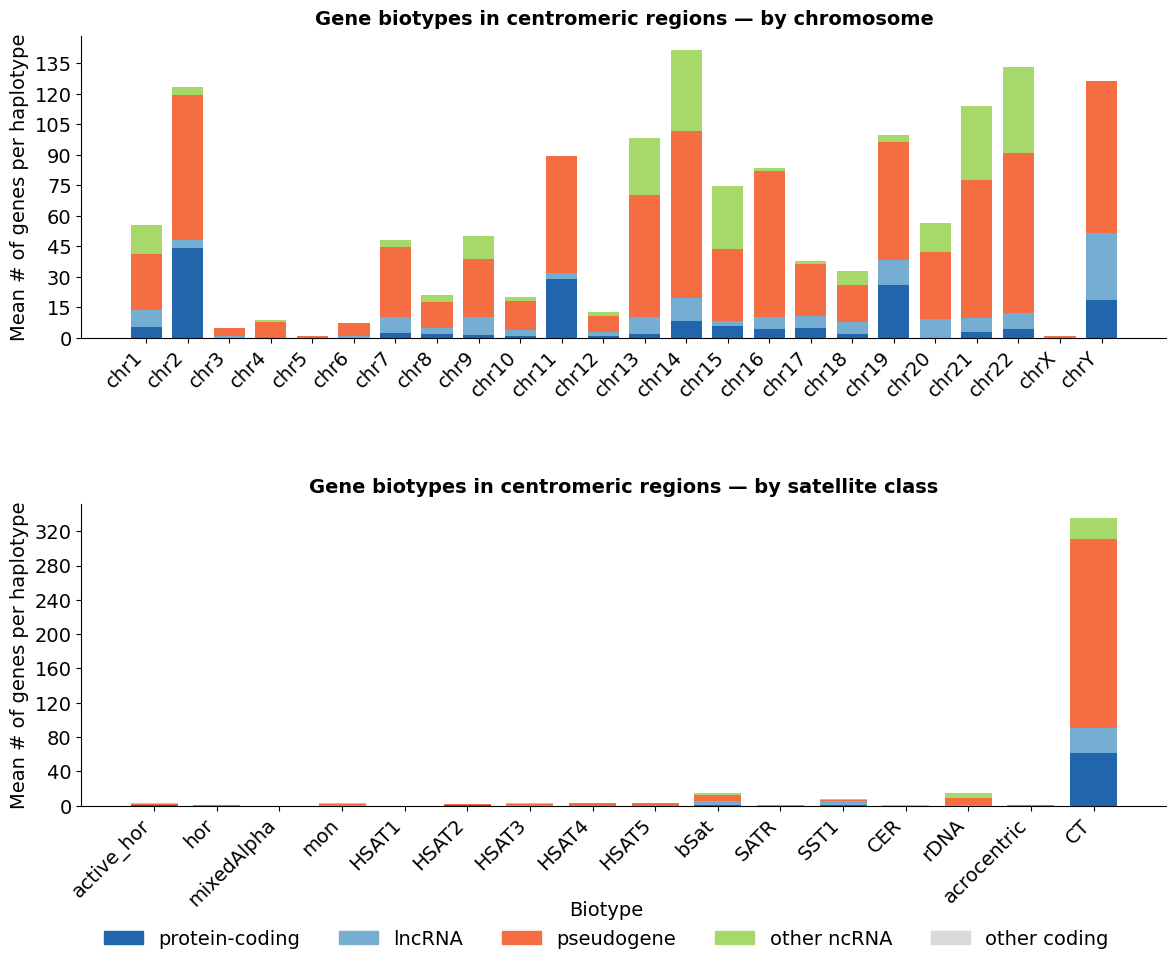

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

IG_TR = {"IG_V_gene", "IG_D_gene", "IG_J_gene", "IG_C_gene",
         "TR_V_gene", "TR_D_gene", "TR_J_gene", "TR_C_gene"}

def classify_biotype_5(b):
    if b == "protein_coding" or b in IG_TR: return "protein-coding"
    elif b == "lncRNA":                      return "lncRNA"
    elif "pseudogene" in b:                  return "pseudogene"
    elif b in ("snRNA", "snoRNA", "miRNA", "rRNA", "misc_RNA"):
                                             return "other ncRNA"
    else:                                    return "other"


# ── pivot tables ──────────────────────────────────────────────────────────────
df["biotype_class"] = df["gene_biotype"].apply(classify_biotype_5)

# count per haplotype first, then average across haplotypes
per_hap = (
    df.groupby(["sample_id", "haplotype", "chrom", "biotype_class"])
    .size()
    .reset_index(name="count")
)

chrom_counts = (
    per_hap.groupby(["chrom", "biotype_class"])["count"]
    .mean()
    .unstack(fill_value=0)
)

sat_counts = (
    df.groupby(["sample_id", "haplotype", "censat_category", "biotype_class"])
    .size()
    .reset_index(name="count")
    .groupby(["censat_category", "biotype_class"])["count"]
    .mean()
    .unstack(fill_value=0)
)


# ── config ────────────────────────────────────────────────────────────────────
BIOTYPE_ORDER = ["protein-coding", "lncRNA", "pseudogene", "other ncRNA", "other coding"]

BIOTYPE_COLORS = {
    "protein-coding": "#2166ac",
    "lncRNA":         "#74add1",
    "pseudogene":     "#f46d43",
    "other ncRNA":    "#a6d96a",
    "other coding":   "#d9d9d9",
}

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

SAT_ORDER = [
    "active_hor", "hor", "dhor", "mixedAlpha", "mon",
    "HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5",
    "bSat", "gSat", "SATR", "SST1", "CER",
    "rDNA", "acrocentric", "CT", "other",
]

# ── plot ──────────────────────────────────────────────────────────────────────
def make_stacked_bar(ax, pivot, title, xlabel, category_order, color_map, biotype_order):
    cols  = [b for b in biotype_order if b in pivot.columns]
    pivot = pivot[cols]
    valid = [c for c in category_order if c in pivot.index]
    pivot = pivot.reindex(valid).fillna(0)

    bottom = np.zeros(len(pivot))
    x      = np.arange(len(pivot))

    for biotype in cols:
        vals = pivot[biotype].values
        ax.bar(x, vals, bottom=bottom,
               color=color_map[biotype], label=biotype,
               width=0.75, linewidth=0)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=14)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel("Mean # of genes per haplotype", fontsize=14)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)


fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.55})

make_stacked_bar(axes[0], chrom_counts,
    title="Gene biotypes in centromeric regions — by chromosome",
    xlabel="", category_order=CHROM_ORDER,
    color_map=BIOTYPE_COLORS, biotype_order=BIOTYPE_ORDER)

make_stacked_bar(axes[1], sat_counts,
    title="Gene biotypes in centromeric regions — by satellite class",
    xlabel="", category_order=SAT_ORDER,
    color_map=BIOTYPE_COLORS, biotype_order=BIOTYPE_ORDER)

handles = [plt.Rectangle((0,0),1,1, color=BIOTYPE_COLORS[b], label=b) for b in BIOTYPE_ORDER]
fig.legend(handles=handles, title="Biotype", loc="lower center",
           ncol=5, fontsize=14, title_fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.05))
#plt.savefig("biotype_summary.pdf", bbox_inches="tight", dpi=200)
plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ── config ────────────────────────────────────────────────────────────────────
BIOTYPE_ORDER = ["protein-coding", "lncRNA"]
BIOTYPE_COLORS = {
    "protein-coding": "#2166ac",
    "lncRNA":         "#74add1",
}

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

SAT_ORDER = [
    "active_hor", "hor", "dhor", "mixedAlpha", "mon",
    "HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5",
    "bSat", "gSat", "SATR", "SST1", "CER",
    "rDNA", "acrocentric", "CT", "other",
]

# ── filter data ───────────────────────────────────────────────────────────────
plot_data = per_hap_chrom[per_hap_chrom["biotype_class"].isin(BIOTYPE_ORDER)].copy()

# only keep satellite classes that have any data
valid_sats = [
    s for s in SAT_ORDER
    if s in plot_data["censat_category"].unique()
] if "censat_category" in plot_data.columns else SAT_ORDER

# we need censat_category in per_hap_chrom — if not, rebuild from df
if "censat_category" not in per_hap_chrom.columns:
    plot_data = (
        df[df["biotype_class"].isin(BIOTYPE_ORDER)]
        .groupby(["sample_id", "haplotype", "chrom", "censat_category", "biotype_class"])
        .size()
        .reset_index(name="count")
    )

valid_sats = [s for s in SAT_ORDER if s in plot_data["censat_category"].unique()]
valid_chroms = [c for c in CHROM_ORDER if c in plot_data["chrom"].unique()]

n_rows = len(valid_chroms)
n_cols = len(valid_sats)

# ── figure ────────────────────────────────────────────────────────────────────
np.random.seed(42)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 1.1, n_rows * 1.4),
    sharex="col",
    sharey="row",
    gridspec_kw={"hspace": 0.15, "wspace": 0.1},
)

# ensure axes is always 2D
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

width  = 0.25   # jitter half-width per biotype
x_pos  = {"protein-coding": -0.18, "lncRNA": 0.18}  # offset per biotype

for r, chrom in enumerate(valid_chroms):
    for c, sat in enumerate(valid_sats):
        ax = axes[r, c]

        sub = plot_data[
            (plot_data["chrom"] == chrom) &
            (plot_data["censat_category"] == sat)
        ]

        has_data = False
        for biotype in BIOTYPE_ORDER:
            vals = sub[sub["biotype_class"] == biotype]["count"].values
            if len(vals) == 0:
                continue
            has_data = True
            color  = BIOTYPE_COLORS[biotype]
            xc     = x_pos[biotype]
            jitter = np.random.uniform(-width * 0.8, width * 0.8, size=len(vals))

            ax.scatter(
                np.full(len(vals), xc) + jitter, vals,
                color=color, alpha=0.4, s=4, linewidths=0, zorder=2
            )
            ax.plot(
                [xc - width * 0.6, xc + width * 0.6],
                [vals.mean(), vals.mean()],
                color=color, lw=1.5, zorder=3
            )

        ax.set_xlim(-0.6, 0.6)
        ax.set_xticks([])
        ax.spines[["top", "right", "bottom"]].set_visible(False)
        ax.tick_params(axis="y", labelsize=5)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=3))

        if not has_data:
            ax.set_facecolor("#f5f5f5")
            ax.spines["left"].set_visible(False)
            ax.set_yticks([])

        # row labels (chrom) on left
        if c == 0:
            ax.set_ylabel(chrom, fontsize=7, rotation=0, labelpad=28, va="center")

        # col labels (sat class) on top
        if r == 0:
            ax.set_title(sat, fontsize=6, rotation=45, ha="left", pad=2)

# ── legend ────────────────────────────────────────────────────────────────────
handles = [
    plt.scatter([], [], color=BIOTYPE_COLORS[b], s=30, label=b)
    for b in BIOTYPE_ORDER
]
fig.legend(
    handles=handles, title="Biotype",
    loc="lower center", ncol=2,
    fontsize=9, title_fontsize=9,
    frameon=False, bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    "Protein-coding & lncRNA genes per chromosome × satellite class",
    fontsize=11, fontweight="bold", y=1.01
)

plt.show()

NameError: name 'per_hap_chrom' is not defined

#### Subset CT genes that are not on the periphery 

In [6]:
import pandas as pd
import glob
import os

CENSAT_BED_DIR  = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
ARRAY_RANGE_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out/beds'

# ── load array ranges ─────────────────────────────────────────────────────────
range_records = []
for bed_path in glob.glob(f'{ARRAY_RANGE_DIR}/*.bed'):
    fname     = os.path.basename(bed_path)      # e.g. HG00097.1.bed
    parts     = fname.replace('.bed','').split('.')
    sample_id = parts[0]
    haplotype = parts[1]

    with open(bed_path) as f:
        for line in f:
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            seq          = cols[0]              # e.g. HG00097#1#CM094060.1
            array_start  = int(cols[1])
            array_end    = int(cols[2])
            chrom        = cols[3]              # e.g. chr1
            range_records.append({
                'sample_id':   sample_id,
                'haplotype':   haplotype,
                'seq':         seq,
                'chrom':       chrom,
                'array_start': array_start,
                'array_end':   array_end,
            })

ranges_df = pd.DataFrame(range_records)
print(f"Loaded {len(ranges_df)} array ranges across {ranges_df['sample_id'].nunique()} samples")
print(ranges_df.head())

Loaded 4084 array ranges across 231 samples
  sample_id haplotype                          seq  chrom  array_start  \
0   NA18970         1  NA18970#1#JBKABU010000018.1  chr18     14129080   
1   NA18970         1         NA18970#1#CM101477.1  chr20     25899967   
2   NA18970         1         NA18970#1#CM101467.1   chr3     90325526   
3   NA18970         1         NA18970#1#CM101473.1  chr12     34178601   
4   NA18970         1  NA18970#1#JBKABU010000019.1  chr19     21001722   

   array_end  
0   20015963  
1   34002937  
2   95683668  
3   38161038  
4   31076511  


In [7]:
# ── load censat BEDs and classify CT intervals ────────────────────────────────
embedded_ct_records = []

for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname     = os.path.basename(bed_path)
    parts     = fname.split('_')
    sample_id = parts[0]
    haplotype = parts[1].replace('hap', '')

    # get array ranges for this sample/haplotype
    sample_ranges = ranges_df[
        (ranges_df['sample_id'] == sample_id) &
        (ranges_df['haplotype'] == haplotype)
    ].set_index('seq')

    if sample_ranges.empty:
        continue

    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'):
                continue
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            seq   = cols[0]
            start = int(cols[1])
            end   = int(cols[2])
            annot = cols[3]
            rows.append({'seq': seq, 'start': start, 'end': end, 'annot': annot})

    if not rows:
        continue

    bed_df = pd.DataFrame(rows)

    # only process CT intervals on contigs we have array ranges for
    ct_df = bed_df[bed_df['annot'].str.match(r'^[Cc][Tt]', na=False)].copy()
    ct_df = ct_df[ct_df['seq'].isin(sample_ranges.index)]

    for _, row in ct_df.iterrows():
        arr        = sample_ranges.loc[row['seq']]
        array_start = arr['array_start']
        array_end   = arr['array_end']
        chrom       = arr['chrom']

        # peripheral if CT interval touches either boundary of the array range
        peripheral = (row['start'] <= array_start) | (row['end'] >= array_end)
        embedded   = not peripheral

        embedded_ct_records.append({
            'sample_id':   sample_id,
            'haplotype':   haplotype,
            'seq':         row['seq'],
            'chrom':       chrom,
            'ct_start':    row['start'],
            'ct_end':      row['end'],
            'annot':       row['annot'],
            'array_start': array_start,
            'array_end':   array_end,
            'embedded':    embedded,
            'peripheral':  peripheral,
        })

embedded_ct_df = pd.DataFrame(embedded_ct_records)

print(f"Total CT intervals:  {len(embedded_ct_df)}")
print(f"Embedded:            {embedded_ct_df['embedded'].sum()}")
print(f"Peripheral:          {embedded_ct_df['peripheral'].sum()}")

Total CT intervals:  33968
Embedded:            29390
Peripheral:          4578


In [8]:
# spot check - embedded CT should be interior to array range
print(embedded_ct_df[embedded_ct_df['embedded']].head(10)[
    ['sample_id', 'chrom', 'ct_start', 'ct_end', 'array_start', 'array_end']
])

  sample_id chrom  ct_start    ct_end  array_start  array_end
0   HG00253  chr6  57831799  58198515     57830918   63012336
1   HG00253  chr6  58224153  58362663     57830918   63012336
2   HG00253  chr6  58371399  58378449     57830918   63012336
3   HG00253  chr6  61535008  61542077     57830918   63012336
4   HG00253  chr6  61557622  61565177     57830918   63012336
5   HG00253  chr6  61639537  61645956     57830918   63012336
6   HG00253  chr6  61751252  62504544     57830918   63012336
7   HG00253  chr6  62531853  62534081     57830918   63012336
8   HG00253  chr6  62536499  62539399     57830918   63012336
9   HG00253  chr6  62553917  62788742     57830918   63012336


In [9]:
# ── filter gene df to embedded CT genes only ──────────────────────────────────
ct_genes = df[df['censat_category'] == 'CT'].copy()
print(f"Total CT genes before filtering: {len(ct_genes)}")

embedded_ct = embedded_ct_df[embedded_ct_df['embedded']].copy()

# merge on sample/haplotype/chrom then filter by coordinate overlap

ct_genes['haplotype']       = ct_genes['haplotype'].astype(str)
embedded_ct['haplotype']    = embedded_ct['haplotype'].astype(str)

ct_genes_embedded = ct_genes.merge(
    embedded_ct[['sample_id', 'haplotype', 'chrom', 'ct_start', 'ct_end']],
    on=['sample_id', 'haplotype', 'chrom'],
    how='inner'
)

# require gene overlaps the CT interval
ct_genes_embedded = ct_genes_embedded[
    (ct_genes_embedded['start'] < ct_genes_embedded['ct_end']) &
    (ct_genes_embedded['end']   > ct_genes_embedded['ct_start'])
].drop(columns=['ct_start', 'ct_end']).drop_duplicates(
    subset=['sample_id', 'haplotype', 'chrom', 'gene_name', 'start', 'end']
).reset_index(drop=True)

print(f"Genes in embedded CT regions:    {len(ct_genes_embedded)}")
print()
print("Biotype breakdown:")
print(ct_genes_embedded['biotype_class'].value_counts())
print()
print("Chromosome breakdown:")
print(ct_genes_embedded['chrom'].value_counts().reindex(CHROM_ORDER).dropna())

Total CT genes before filtering: 154669
Genes in embedded CT regions:    66603

Biotype breakdown:
biotype_class
pseudogene        43737
protein-coding    10419
lncRNA             5646
other ncRNA        4551
other coding       2250
Name: count, dtype: int64

Chromosome breakdown:
chrom
chr1      2289.0
chr2      7316.0
chr3       195.0
chr4       510.0
chr6       675.0
chr7      5459.0
chr8      2339.0
chr9      3798.0
chr10     2352.0
chr11    16497.0
chr12      853.0
chr13      162.0
chr14      762.0
chr15      114.0
chr16     4847.0
chr17     2114.0
chr18     1827.0
chr19    10429.0
chr20     3463.0
chr22      219.0
chrY       383.0
Name: count, dtype: float64


#### combine CT embedded and the rest of the sat classes

In [10]:
# non-CT genes from original df
non_ct_genes = df[df['censat_category'] != 'CT'].copy()

# combine with embedded CT genes
df_filtered = pd.concat([non_ct_genes, ct_genes_embedded], ignore_index=True)

print(f"Non-CT genes:          {len(non_ct_genes)}")
print(f"Embedded CT genes:     {len(ct_genes_embedded)}")
print(f"Total after filtering: {len(df_filtered)}")
print(df_filtered['censat_category'].value_counts())

Non-CT genes:          15932
Embedded CT genes:     66603
Total after filtering: 82535
censat_category
CT             66603
bSat            5358
rDNA            4996
SST1            2068
HSAT5           1468
HSAT4            634
mon              528
CER              255
hor              213
SATR             138
active_hor        96
HSAT3             88
HSAT1             68
HSAT2             11
acrocentric        8
GAP                2
mixedAlpha         1
Name: count, dtype: int64


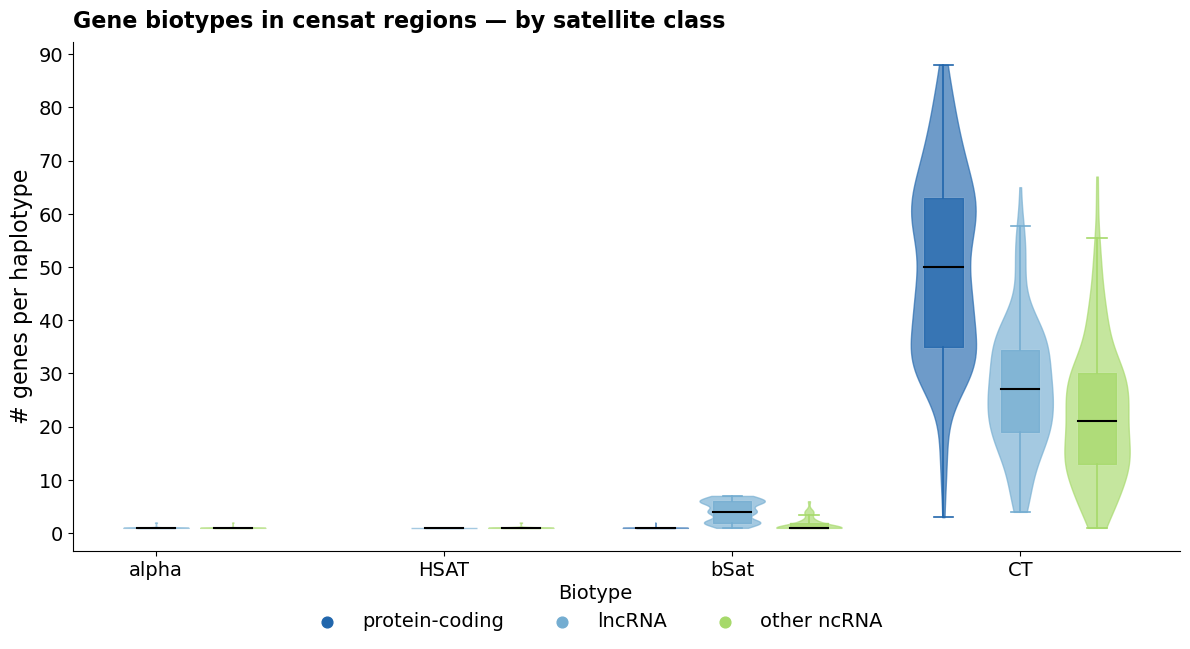

In [54]:
BIOTYPE_ORDER = ["protein-coding", "lncRNA", "other ncRNA"]

BIOTYPE_COLORS = {
    "protein-coding": "#2166ac",
    "lncRNA":         "#74add1",
    "pseudogene":     "#f46d43",
    "other ncRNA":    "#a6d96a",
    "other coding":   "#d9d9d9",
}

SAT_GROUPS = {
    "alpha": ["active_hor", "hor", "mixedAlpha", "mon"],
    "HSAT":  ["HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5"],
    "bSat":  ["bSat"],
    "CT":    ["CT"],
}
SAT_ORDER_NEW = ["alpha", "HSAT", "bSat", "CT"]
cat_to_satgrp = {c: g for g, cats in SAT_GROUPS.items() for c in cats}

df_filtered_sat = df_filtered.copy()
df_filtered_sat["sat_group"] = df_filtered_sat["censat_category"].map(cat_to_satgrp)
df_filtered_sat = df_filtered_sat.dropna(subset=["sat_group"])

per_hap_sat_condensed = (
    df_filtered_sat
    .groupby(["sample_id", "haplotype", "sat_group", "biotype_class"])
    .size()
    .reset_index(name="count")
)

def make_swarm_panel(ax, data, x_col, x_order, title, xlabel):
    valid_x       = [c for c in x_order if c in data[x_col].unique()]
    valid_biotype = [b for b in BIOTYPE_ORDER if b in data["biotype_class"].unique()]
    data          = data[data[x_col].isin(valid_x)]

    n_biotypes = len(valid_biotype)
    width      = 0.8 / n_biotypes
    x_idx      = {c: i for i, c in enumerate(valid_x)}

    for b_i, biotype in enumerate(valid_biotype):
        sub    = data[data["biotype_class"] == biotype]
        color  = BIOTYPE_COLORS[biotype]
        offset = (b_i - n_biotypes / 2 + 0.5) * width

        for cat in valid_x:
            vals = sub[sub[x_col] == cat]["count"].values
            if len(vals) < 3:
                continue
            xi = x_idx[cat] + offset

            # violin with outline
            parts = ax.violinplot(vals, positions=[xi], widths=width * 0.85,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.65)
                pc.set_edgecolor(color)
                pc.set_linewidth(1.0)

            # box and whiskers
            q1, med, q3 = np.percentile(vals, [25, 50, 75])
            iqr   = q3 - q1
            lo    = max(vals.min(), q1 - 1.5 * iqr)
            hi    = min(vals.max(), q3 + 1.5 * iqr)
            bw    = width * 0.25
            ax.fill_between([xi - bw, xi + bw], q1, q3,
                             color="white", zorder=3)
            ax.fill_between([xi - bw, xi + bw], q1, q3,
                             color=color, alpha=0.9, zorder=4)
            ax.plot([xi - bw, xi + bw], [med, med],
                    color="black", lw=1.5, zorder=5)
            ax.plot([xi, xi], [lo, q1], color=color, lw=1.2, zorder=3)
            ax.plot([xi, xi], [q3, hi], color=color, lw=1.2, zorder=3)
            ax.plot([xi - bw * 0.5, xi + bw * 0.5], [lo, lo],
                    color=color, lw=1.2, zorder=3)
            ax.plot([xi - bw * 0.5, xi + bw * 0.5], [hi, hi],
                    color=color, lw=1.2, zorder=3)

    ax.set_xticks(range(len(valid_x)))
    ax.set_xticklabels(valid_x, ha="center", fontsize=14)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=10, loc="left")
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel("# genes per haplotype", fontsize=16)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)

np.random.seed(42)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

make_swarm_panel(
    ax, per_hap_sat_condensed,
    x_col="sat_group", x_order=SAT_ORDER_NEW,
    title="Gene biotypes in censat regions — by satellite class",
    xlabel=""
)

handles = [
    plt.scatter([], [], color=BIOTYPE_COLORS[b], s=60, label=b)
    for b in BIOTYPE_ORDER if b in df_filtered_sat["biotype_class"].unique()
]
fig.legend(
    handles=handles, title="Biotype",
    loc="lower center", ncol=5,
    fontsize=14, title_fontsize=14,
    frameon=False, bbox_to_anchor=(0.5, -0.09)
)

plt.tight_layout()
plt.show()



In [49]:
df[df["gene_biotype"].apply(classify_biotype_5) == "other"]["gene_biotype"].value_counts()


gene_biotype
unknown_likely_coding    245
Mt_rRNA                   54
Mt_tRNA                   48
Name: count, dtype: int64

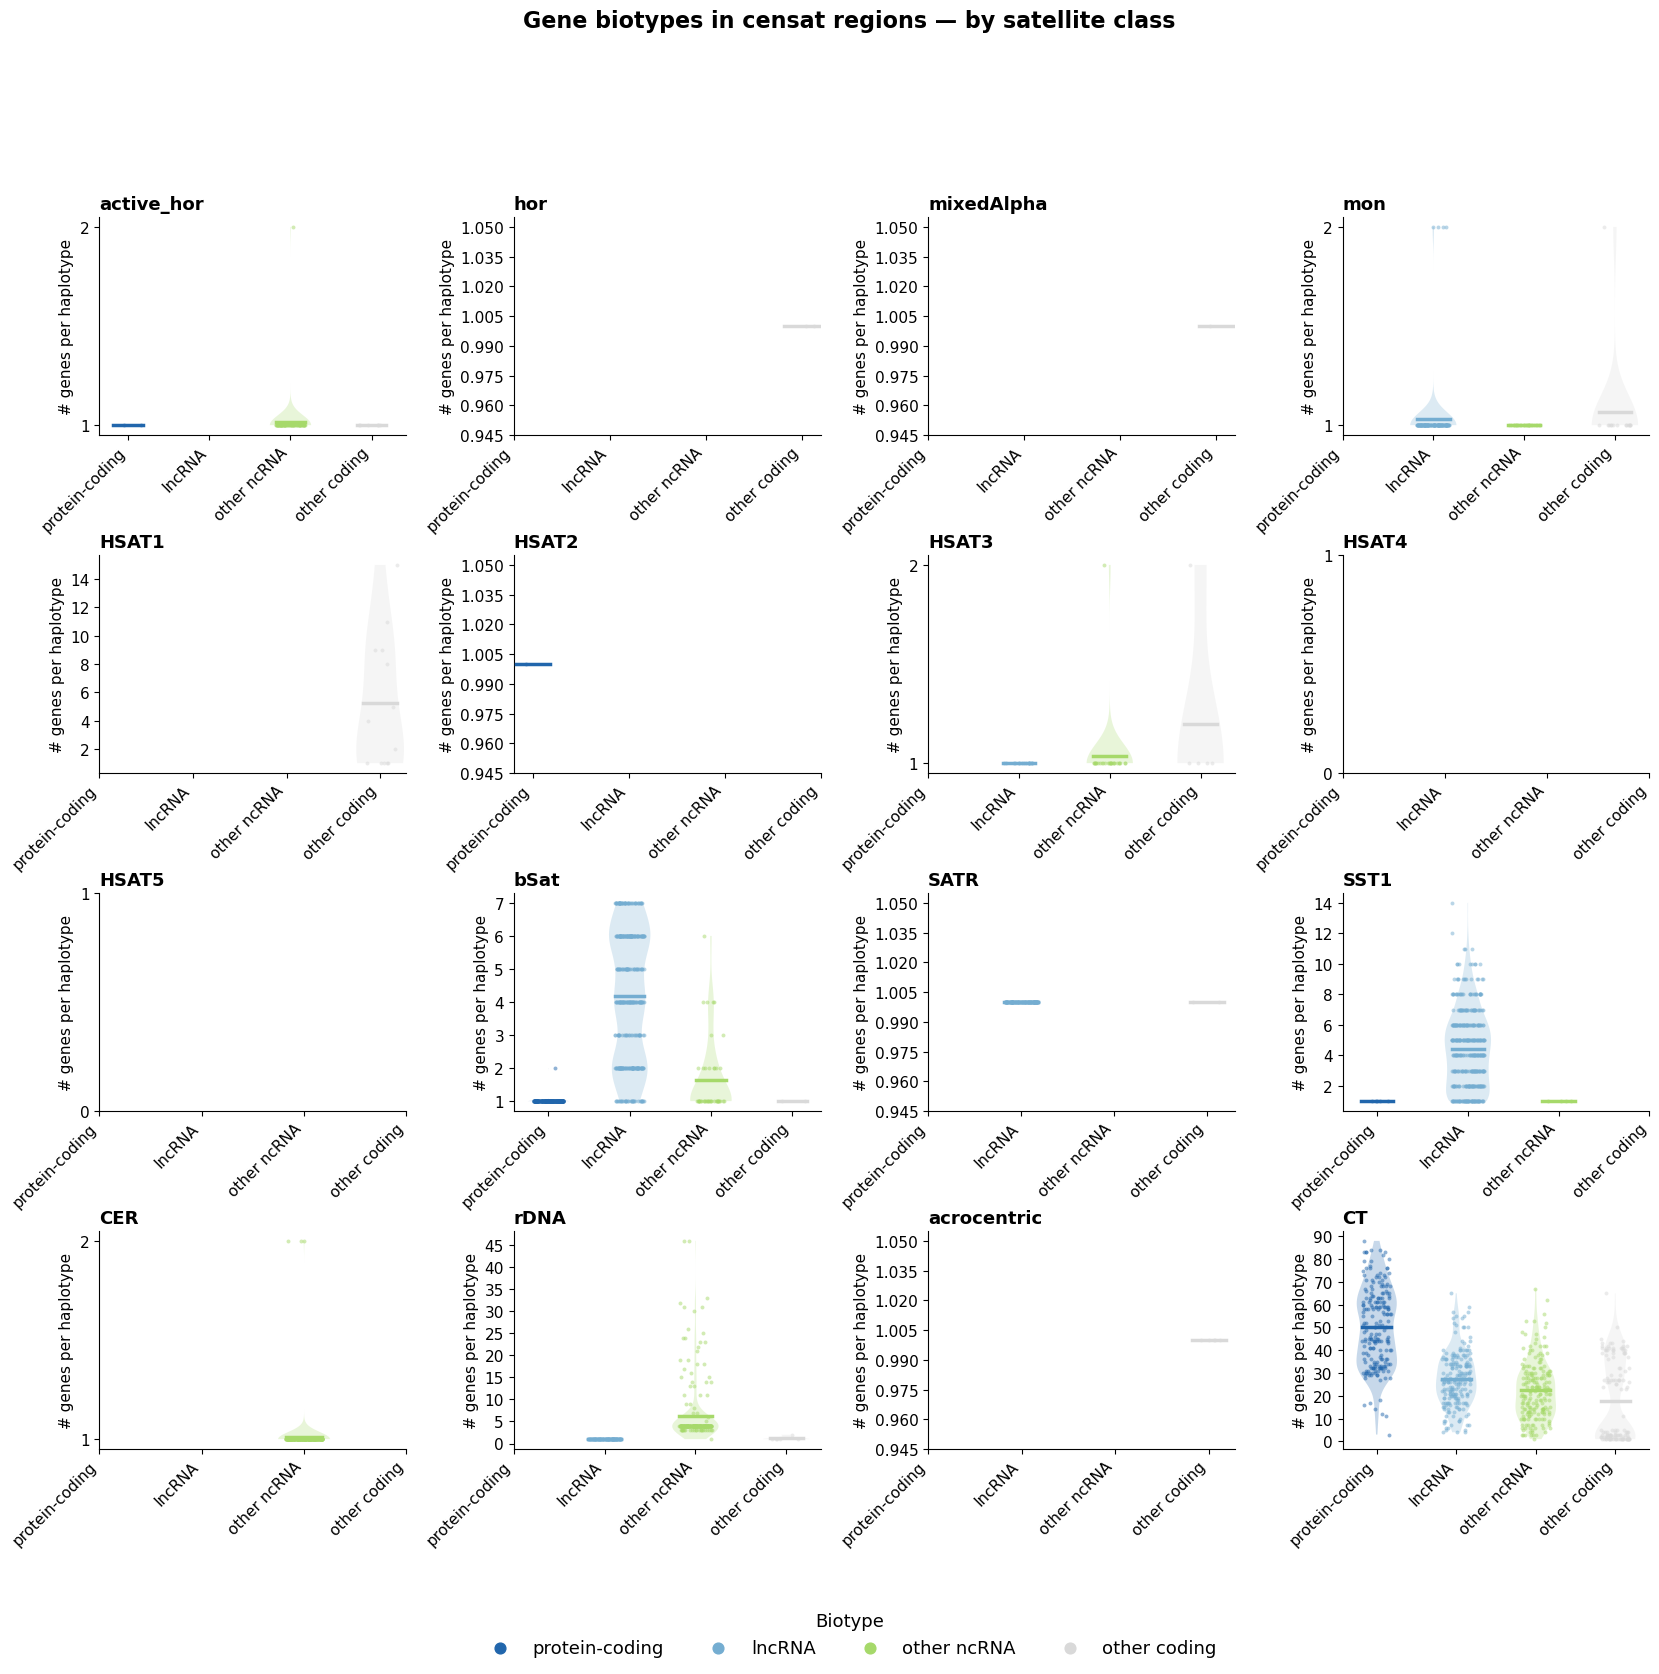

In [40]:
np.random.seed(42)

valid_cats    = [c for c in SAT_ORDER if c in per_hap_sat_filt["censat_category"].unique()]
valid_biotype = [b for b in BIOTYPE_ORDER if b in per_hap_sat_filt["biotype_class"].unique()]

ncols = 4
nrows = (len(valid_cats) + ncols - 1) // ncols
width = 0.6
x_idx = {b: i for i, b in enumerate(valid_biotype)}

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4),
                         gridspec_kw={"hspace": 0.55, "wspace": 0.35})
axes = axes.flatten()

for ax_i, cat in enumerate(valid_cats):
    ax      = axes[ax_i]
    sub_cat = per_hap_sat_filt[per_hap_sat_filt["censat_category"] == cat]

    for biotype in valid_biotype:
        sub   = sub_cat[sub_cat["biotype_class"] == biotype]
        vals  = sub["count"].values
        color = BIOTYPE_COLORS[biotype]
        xi    = x_idx[biotype]

        if len(vals) == 0:
            continue

        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=width * 0.85,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.25)
                pc.set_edgecolor("none")

        jitter = np.random.uniform(-width * 0.3, width * 0.3, size=len(vals))
        ax.scatter(np.full(len(vals), xi) + jitter, vals,
                   color=color, alpha=0.5, s=8, linewidths=0, zorder=3)
        ax.plot([xi - width * 0.3, xi + width * 0.3],
                [vals.mean(), vals.mean()],
                color=color, lw=2.5, zorder=4)

    ax.set_xticks(range(len(valid_biotype)))
    ax.set_xticklabels(valid_biotype, rotation=45, ha="right", fontsize=11)
    ax.set_title(cat, fontsize=13, fontweight="bold", pad=6, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=11)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=11)

for ax_i in range(len(valid_cats), len(axes)):
    axes[ax_i].set_visible(False)

handles = [plt.scatter([], [], color=BIOTYPE_COLORS[b], s=60, label=b) for b in BIOTYPE_ORDER]
fig.legend(handles=handles, title="Biotype", loc="lower center", ncol=5,
           fontsize=13, title_fontsize=13, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Gene biotypes in censat regions — by satellite class",
             fontsize=16, fontweight="bold", y=1.01)
plt.show()


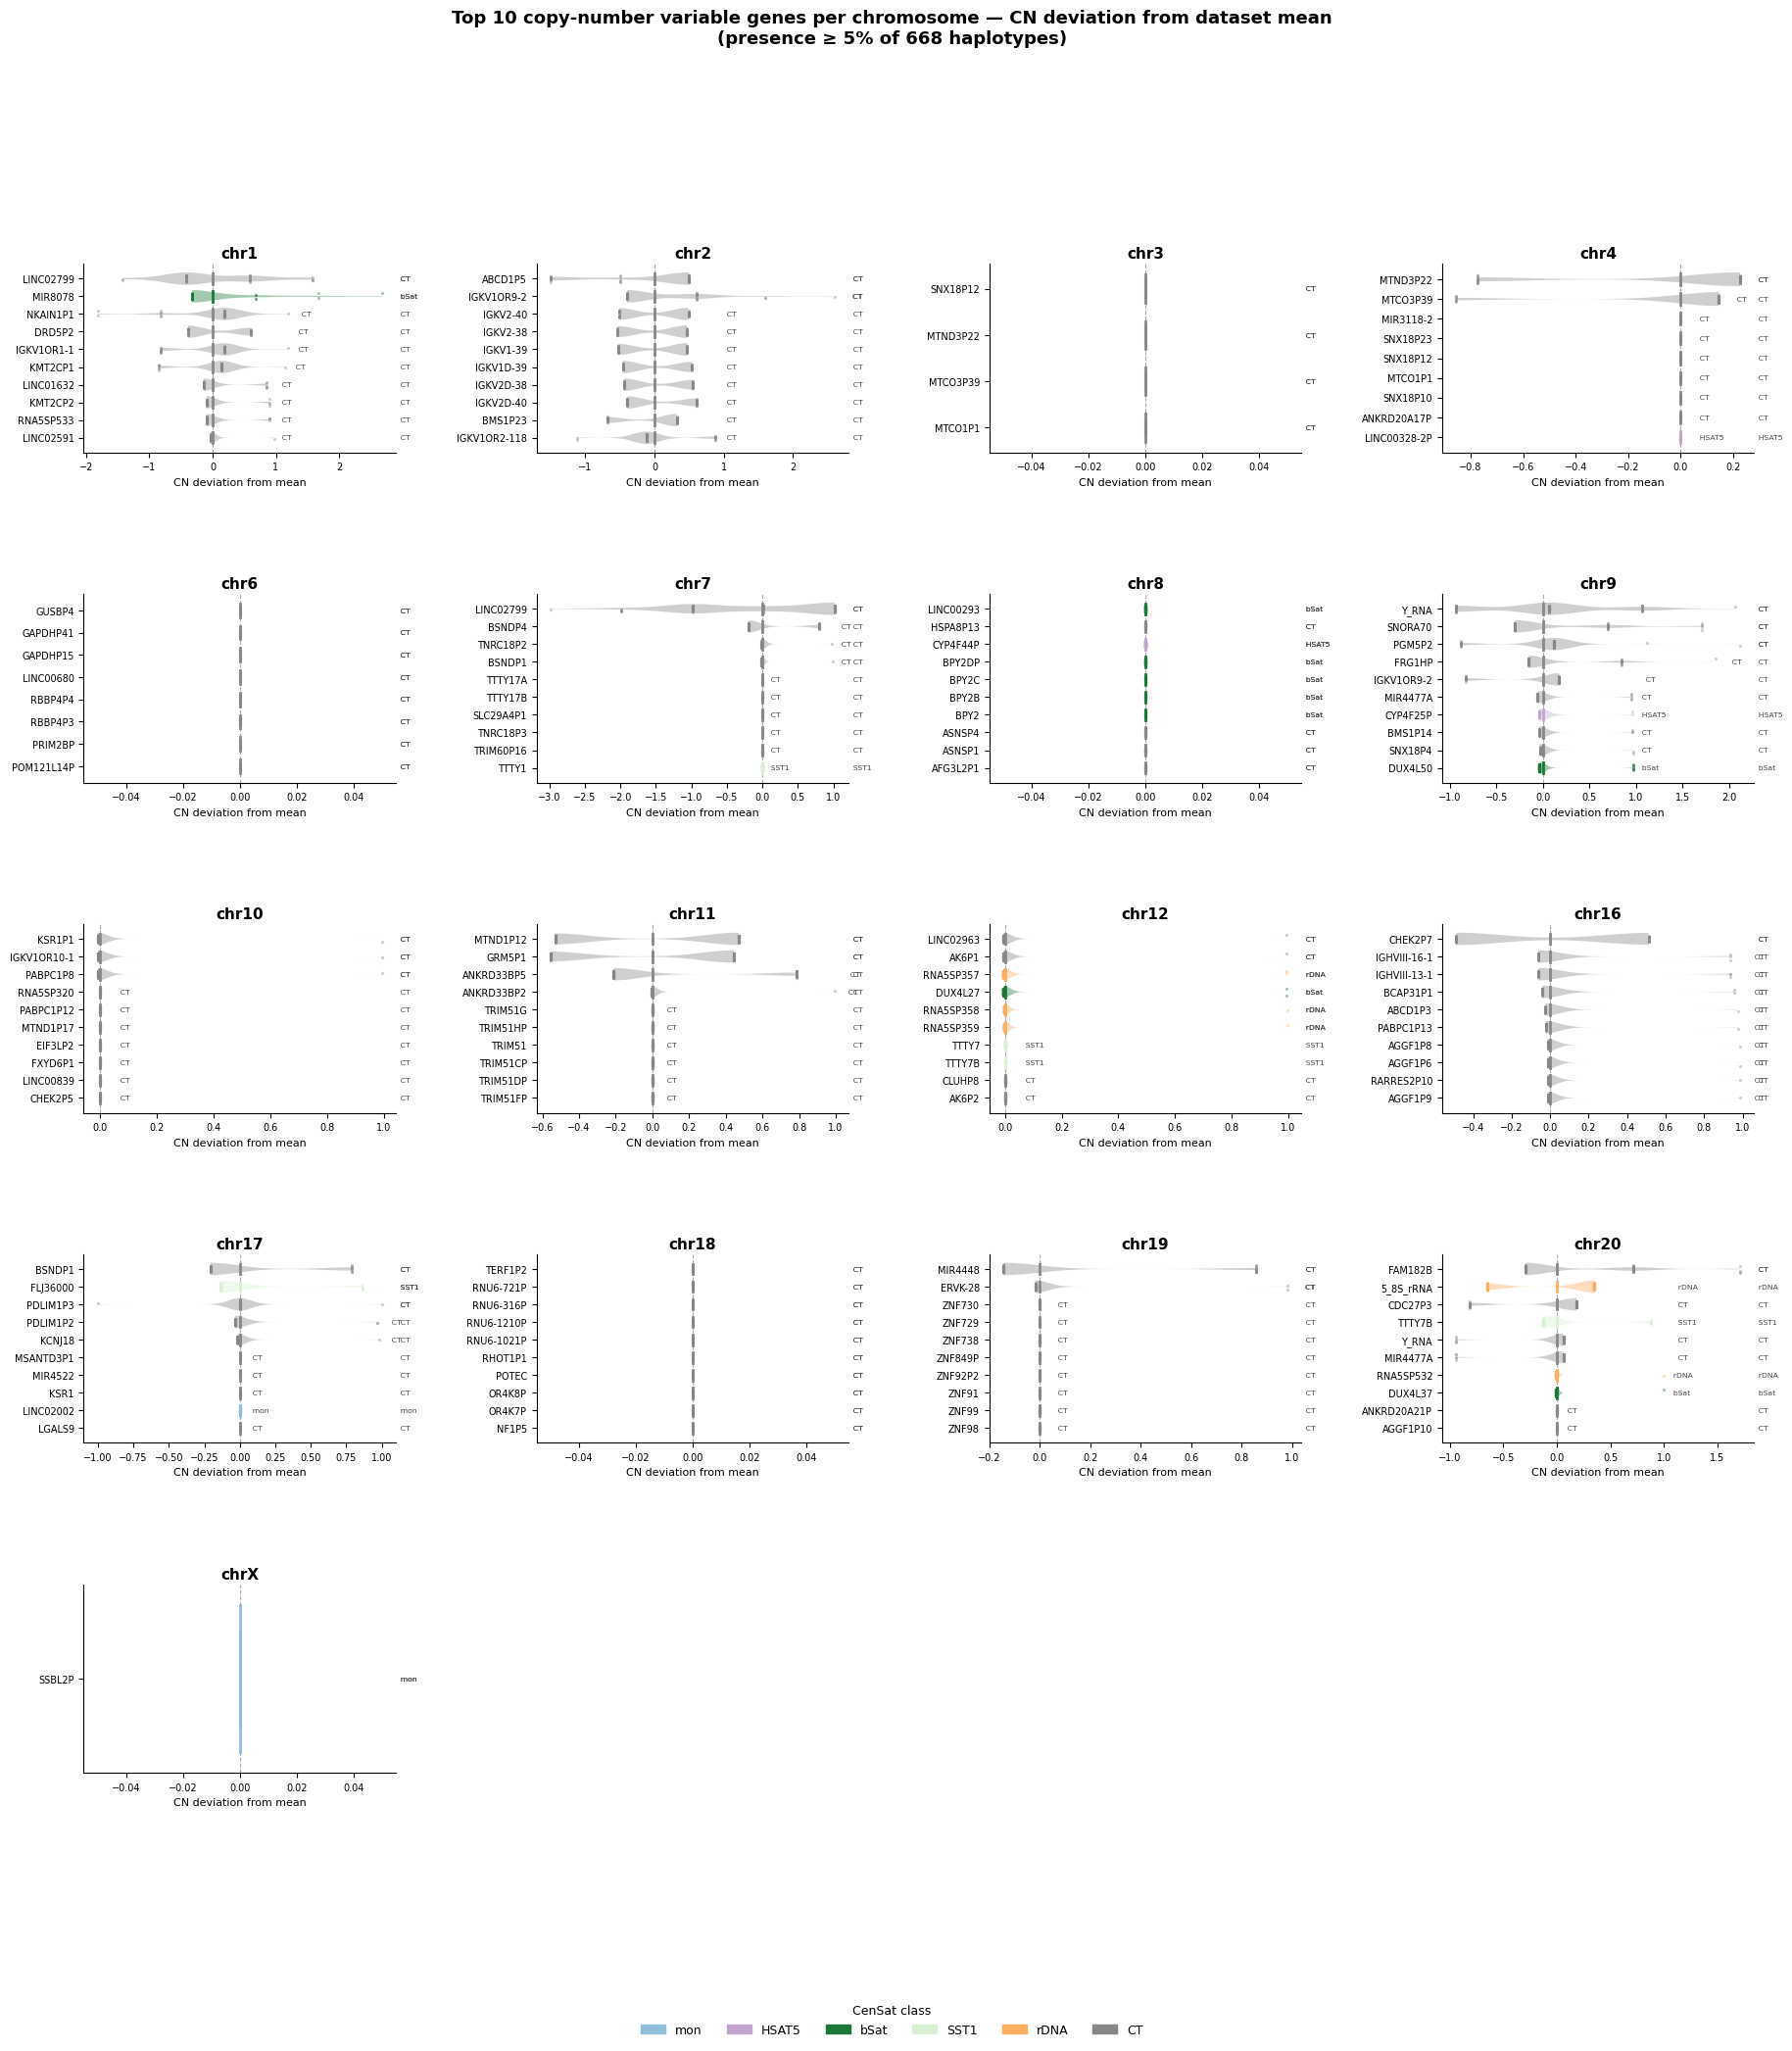

In [13]:
# ── compute CN deviation from dataset mean per gene ───────────────────────────
total_haplotypes = df_filtered[['sample_id', 'haplotype']].drop_duplicates().shape[0]

# count copies per gene per haplotype
gene_cn = (
    df_filtered
    .groupby(['sample_id', 'haplotype', 'chrom', 'gene_name'])
    .size()
    .reset_index(name='copy_number')
)

# dataset-wide mean CN per gene (across haplotypes that have it)
gene_mean = (
    gene_cn
    .groupby(['chrom', 'gene_name'])['copy_number']
    .mean()
    .reset_index(name='cn_mean')
)

# join mean back and compute deviation
gene_cn = gene_cn.merge(gene_mean, on=['chrom', 'gene_name'])
gene_cn['cn_dev'] = gene_cn['copy_number'] - gene_cn['cn_mean']

# summary stats for ranking
gene_stats = (
    gene_cn
    .groupby(['chrom', 'gene_name'])
    .agg(
        cn_mean      = ('copy_number', 'mean'),
        cn_std       = ('copy_number', 'std'),
        n_haplotypes = ('copy_number', 'count'),
    )
    .reset_index()
)
gene_stats['presence_freq'] = gene_stats['n_haplotypes'] / total_haplotypes
gene_stats['cn_std']        = gene_stats['cn_std'].fillna(0)

# add dominant censat_category and biotype per gene
gene_meta = (
    df_filtered.groupby(['chrom', 'gene_name'])
    .agg(
        censat_category = ('censat_category', lambda x: x.value_counts().index[0]),
        biotype_class   = ('biotype_class',   lambda x: x.value_counts().index[0]),
    )
    .reset_index()
)
gene_stats = gene_stats.merge(gene_meta, on=['chrom', 'gene_name'])

# ── top 10 per chrom by CN std (rank by spread of deviation) ─────────────────
min_presence    = 0.05
gene_stats_filt = gene_stats[gene_stats['presence_freq'] >= min_presence]

top10_per_chrom = (
    gene_stats_filt
    .sort_values('cn_std', ascending=False)
    .groupby('chrom')
    .head(10)
    .reset_index(drop=True)
)

# ── satellite class colors ────────────────────────────────────────────────────
SAT_COLORS = {
    "active_hor":  "#d73027",
    "hor":         "#fc8d59",
    "dhor":        "#fee090",
    "mixedAlpha":  "#e0f3f8",
    "mon":         "#91bfdb",
    "HSAT1":       "#4575b4",
    "HSAT2":       "#313695",
    "HSAT3":       "#762a83",
    "HSAT4":       "#9970ab",
    "HSAT5":       "#c2a5cf",
    "bSat":        "#1b7837",
    "gSat":        "#5aae61",
    "SATR":        "#a6dba0",
    "SST1":        "#d9f0d3",
    "CER":         "#f46d43",
    "rDNA":        "#fdae61",
    "acrocentric": "#fee08b",
    "CT":          "#878787",
    "other":       "#cccccc",
}

# ── plot ──────────────────────────────────────────────────────────────────────
valid_chroms = [c for c in CHROM_ORDER if c in top10_per_chrom['chrom'].unique()]
n_cols       = 4
n_rows       = int(np.ceil(len(valid_chroms) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 5.5, n_rows * 4),
    gridspec_kw={"hspace": 0.75, "wspace": 0.45},
)
axes = axes.flatten()

for idx, chrom in enumerate(valid_chroms):
    ax = axes[idx]

    # get top 10 genes for this chrom, sorted by cn_std descending
    top_genes = (
        top10_per_chrom[top10_per_chrom['chrom'] == chrom]
        .sort_values('cn_std', ascending=True)   # ascending so highest is at top after invert
        ['gene_name'].tolist()
    )

    for g_i, gene in enumerate(top_genes):
        # get per-haplotype CN deviations for this gene
        devs = gene_cn[
            (gene_cn['chrom'] == chrom) &
            (gene_cn['gene_name'] == gene)
        ]['cn_dev'].values

        sat = gene_stats[
            (gene_stats['chrom'] == chrom) &
            (gene_stats['gene_name'] == gene)
        ]['censat_category'].values[0]

        color = SAT_COLORS.get(sat, '#cccccc')

        # violin
        if len(devs) >= 3:
            parts = ax.violinplot(
                devs, positions=[g_i],
                vert=False,
                widths=0.7,
                showextrema=False,
                showmedians=False,
            )
            for pc in parts['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.4)
                pc.set_edgecolor('none')

        # jittered scatter
        jitter = np.random.uniform(-0.2, 0.2, size=len(devs))
        ax.scatter(
            devs, np.full(len(devs), g_i) + jitter,
            color=color, alpha=0.4, s=5, linewidths=0, zorder=3
        )

        # mean line at 0 deviation reference
        ax.plot(
            [devs.mean(), devs.mean()],
            [g_i - 0.3, g_i + 0.3],
            color=color, lw=2, zorder=4
        )

        # satellite class label on right
        ax.text(
            ax.get_xlim()[1] if ax.get_xlim()[1] != 0 else 1,
            g_i, f"  {sat}",
            va='center', fontsize=5.5, color='#444'
        )

    # reference line at 0
    ax.axvline(0, color='#aaa', lw=0.8, ls='--', zorder=1)

    ax.set_yticks(range(len(top_genes)))
    ax.set_yticklabels(top_genes, fontsize=7)
    ax.set_title(chrom, fontsize=11, fontweight='bold', pad=4)
    ax.set_xlabel("CN deviation from mean", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)

# fix satellite labels after xlim is set
# (re-draw after plot to get correct xlim)
for idx, chrom in enumerate(valid_chroms):
    ax = axes[idx]
    top_genes = (
        top10_per_chrom[top10_per_chrom['chrom'] == chrom]
        .sort_values('cn_std', ascending=True)
        ['gene_name'].tolist()
    )
    xmax = ax.get_xlim()[1]
    for g_i, gene in enumerate(top_genes):
        sat = gene_stats[
            (gene_stats['chrom'] == chrom) &
            (gene_stats['gene_name'] == gene)
        ]['censat_category'].values[0]
        ax.text(
            xmax, g_i, f"  {sat}",
            va='center', fontsize=5.5, color='#444',
            clip_on=False
        )

# hide unused subplots
for idx in range(len(valid_chroms), len(axes)):
    axes[idx].set_visible(False)

# ── legend ────────────────────────────────────────────────────────────────────
present_sats = top10_per_chrom['censat_category'].unique()
handles = [
    plt.Rectangle((0, 0), 1, 1, color=SAT_COLORS.get(s, '#cccccc'), label=s)
    for s in SAT_ORDER if s in present_sats
]
fig.legend(
    handles=handles, title="CenSat class",
    loc="lower center", ncol=8,
    fontsize=9, title_fontsize=9,
    frameon=False, bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    f"Top 10 copy-number variable genes per chromosome — CN deviation from dataset mean\n"
    f"(presence ≥ {int(min_presence*100)}% of {total_haplotypes} haplotypes)",
    fontsize=13, fontweight='bold', y=1.01
)

plt.show()

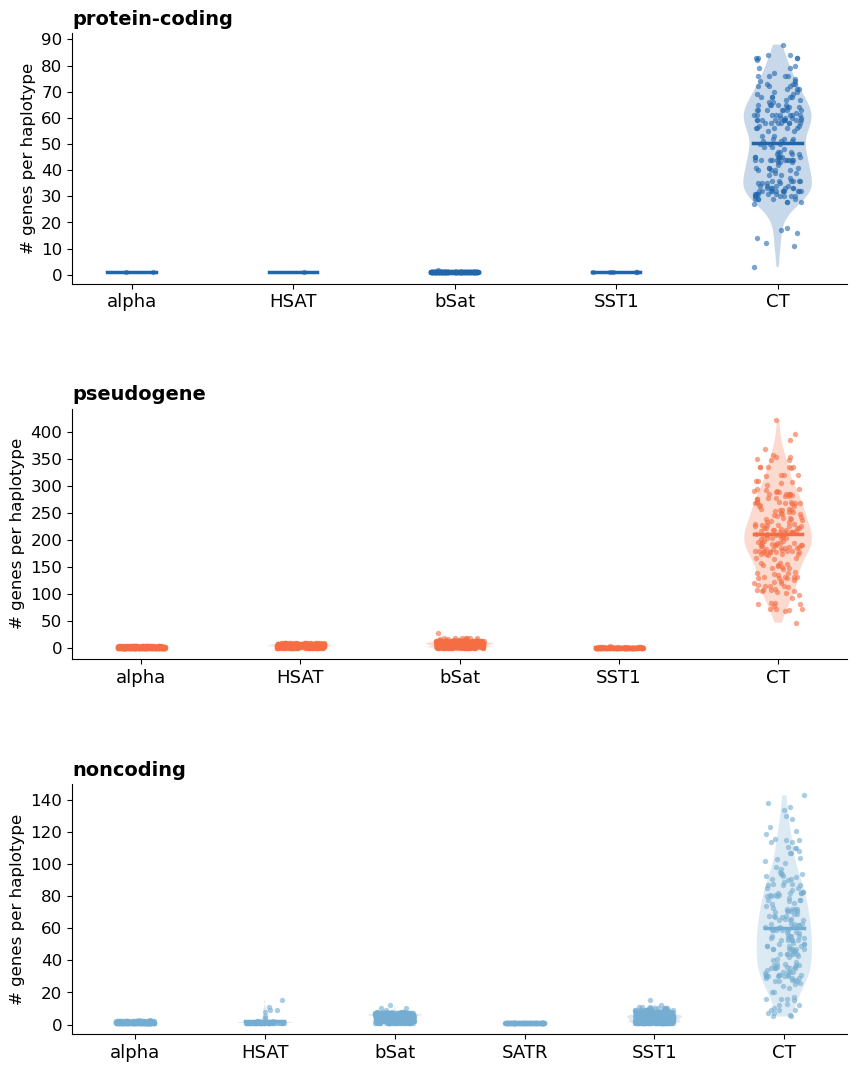

In [15]:
np.random.seed(42)

# --- group definitions ---
BIOTYPE_MAP = {
    "protein-coding": ["protein-coding"],
    "pseudogene":     ["pseudogene"],
    "noncoding":      ["lncRNA", "other ncRNA", "other coding"],
}
SAT_GROUPS = {
    "alpha": ["active_hor", "hor", "mixedAlpha", "mon"],
    "HSAT":  ["HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5"],
    "bSat":  ["bSat"],
    "SATR":  ["SATR"],
    "SST1":  ["SST1"],
    "CT":    ["CT"],
}
SAT_ORDER_NEW    = ["alpha", "HSAT", "bSat", "SATR", "SST1", "CT"]
BIOTYPE_ORDER_3  = ["protein-coding", "pseudogene", "noncoding"]
BIOTYPE_COLORS_3 = {"protein-coding": "#2166ac", "pseudogene": "#f46d43", "noncoding": "#74add1"}

cat_to_satgrp  = {c: g for g, cats in SAT_GROUPS.items() for c in cats}
bio_to_biogrp  = {b: g for g, bs in BIOTYPE_MAP.items() for b in bs}

# --- build plot dataframe ---
df_plot = df_filtered.copy()
df_plot["sat_group"]    = df_plot["censat_category"].map(cat_to_satgrp)
df_plot["biotype_group"] = df_plot["biotype_class"].map(bio_to_biogrp)
df_plot = df_plot.dropna(subset=["sat_group", "biotype_group"])

per_hap = (
    df_plot
    .groupby(["sample_id", "haplotype", "sat_group", "biotype_group"])
    .size()
    .reset_index(name="count")
)

# --- plot ---
width = 0.5
fig, axes = plt.subplots(3, 1, figsize=(10, 13), gridspec_kw={"hspace": 0.5})

for ax, biotype_grp in zip(axes, BIOTYPE_ORDER_3):
    sub   = per_hap[per_hap["biotype_group"] == biotype_grp]
    color = BIOTYPE_COLORS_3[biotype_grp]
    valid_sats = [s for s in SAT_ORDER_NEW if s in sub["sat_group"].unique()]

    for xi, sat in enumerate(valid_sats):
        vals = sub[sub["sat_group"] == sat]["count"].values
        if len(vals) == 0:
            continue

        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=width * 0.85,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.25)
                pc.set_edgecolor("none")

        jitter = np.random.uniform(-width * 0.3, width * 0.3, size=len(vals))
        ax.scatter(np.full(len(vals), xi) + jitter, vals,
                   color=color, alpha=0.6, s=15, linewidths=0, zorder=3)
        ax.plot([xi - width * 0.3, xi + width * 0.3],
                [vals.mean(), vals.mean()],
                color=color, lw=2.5, zorder=4)

    ax.set_xticks(range(len(valid_sats)))
    ax.set_xticklabels(valid_sats, fontsize=13)
    ax.set_title(biotype_grp, fontsize=14, fontweight="bold", pad=6, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

plt.show()


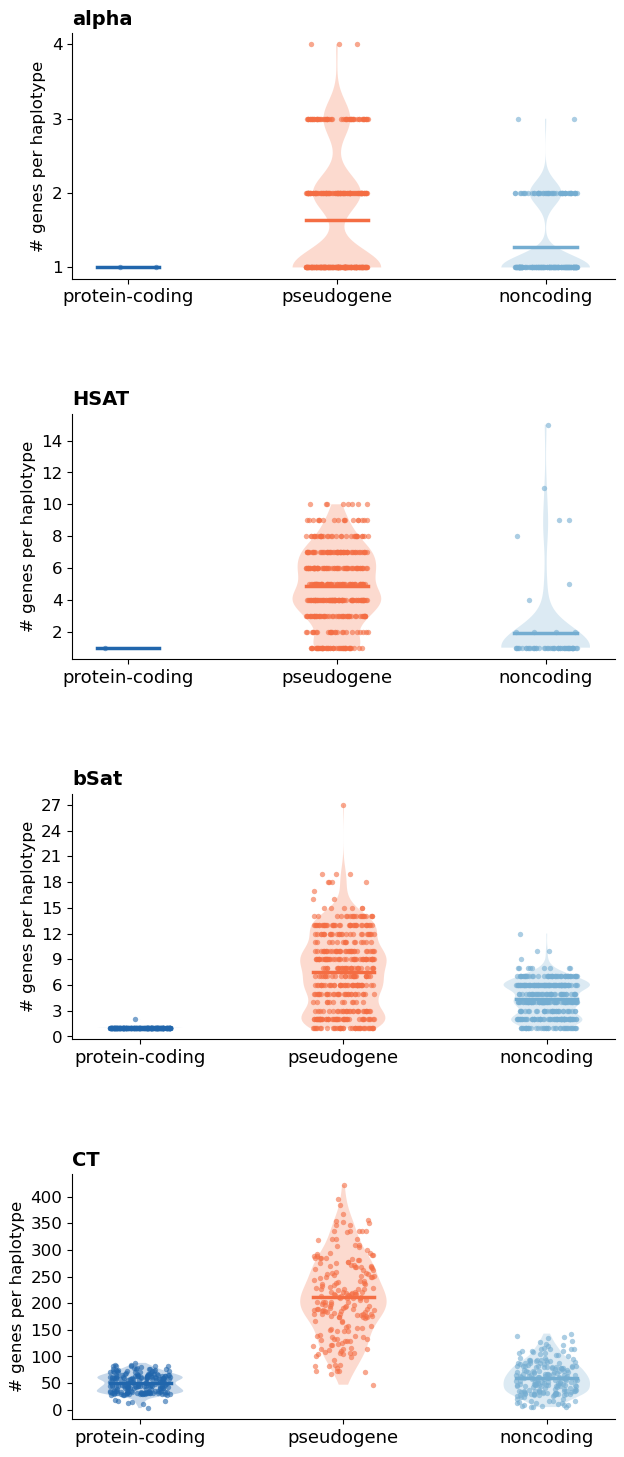

In [17]:
np.random.seed(42)

SAT_ORDER_NEW = ["alpha", "HSAT", "bSat", "CT"]


width = 0.5
fig, axes = plt.subplots(len(SAT_ORDER_NEW), 1, figsize=(7, 18),
                         gridspec_kw={"hspace": 0.55})

for ax, sat_grp in zip(axes, SAT_ORDER_NEW):
    sub         = per_hap[per_hap["sat_group"] == sat_grp]
    valid_bios  = [b for b in BIOTYPE_ORDER_3 if b in sub["biotype_group"].unique()]

    for xi, biotype_grp in enumerate(valid_bios):
        vals  = sub[sub["biotype_group"] == biotype_grp]["count"].values
        color = BIOTYPE_COLORS_3[biotype_grp]
        if len(vals) == 0:
            continue

        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=width * 0.85,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.25)
                pc.set_edgecolor("none")

        jitter = np.random.uniform(-width * 0.3, width * 0.3, size=len(vals))
        ax.scatter(np.full(len(vals), xi) + jitter, vals,
                   color=color, alpha=0.6, s=15, linewidths=0, zorder=3)
        ax.plot([xi - width * 0.3, xi + width * 0.3],
                [vals.mean(), vals.mean()],
                color=color, lw=2.5, zorder=4)

    ax.set_xticks(range(len(valid_bios)))
    ax.set_xticklabels(valid_bios, fontsize=13)
    ax.set_title(sat_grp, fontsize=14, fontweight="bold", pad=6, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

plt.show()


Total haplotypes: 461


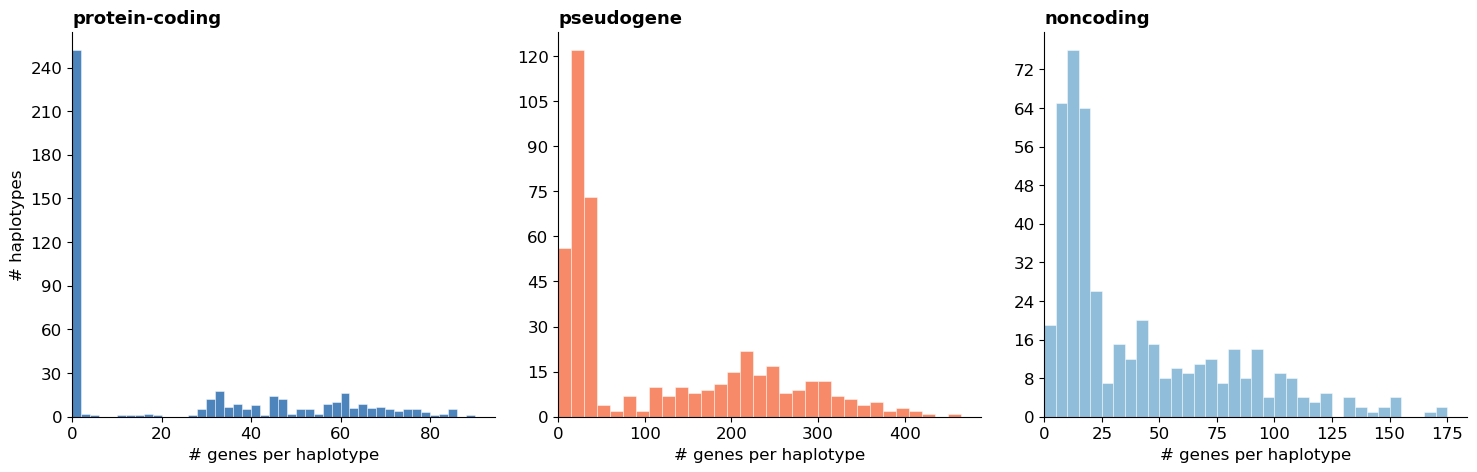

55.3% of haplotypes have <10 protein-coding:   (n=461)
6.1% of haplotypes have <10 pseudogene:   (n=461)
18.2% of haplotypes have <10 noncoding:   (n=461)


In [63]:
import numpy as np

df_filtered["haplotype"] = df_filtered["haplotype"].astype(str)

# rebuild biotype grouping
bio_to_biogrp = {b: g for g, bs in BIOTYPE_MAP.items() for b in bs}
df_filtered["biotype_group"] = df_filtered["biotype_class"].map(bio_to_biogrp)
df_plot = df_filtered.dropna(subset=["biotype_group"])

per_hap_bio = (
    df_plot
    .groupby(["sample_id", "haplotype", "biotype_group"])
    .size()
    .reset_index(name="count")
)

all_haps = df_filtered[["sample_id", "haplotype"]].drop_duplicates().reset_index(drop=True)
print(f"Total haplotypes: {len(all_haps)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"wspace": 0.15})

for ax, bio in zip(axes, BIOTYPE_ORDER_3):
    sub    = per_hap_bio[per_hap_bio["biotype_group"] == bio][["sample_id", "haplotype", "count"]]
    merged = all_haps.merge(sub, on=["sample_id", "haplotype"], how="left").fillna(0)
    vals   = merged["count"].values
    color  = BIOTYPE_COLORS_3[bio]

    step = max(1, int(vals.max()) // 30)
    bins = range(0, int(vals.max()) + step + 1, step)
    ax.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)

    ax.set_title(bio, fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("# genes per haplotype", fontsize=12)
    ax.set_ylabel("# haplotypes" if bio == BIOTYPE_ORDER_3[0] else "", fontsize=12)
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)

plt.show()

for bio in BIOTYPE_ORDER_3:
    sub    = per_hap_bio[per_hap_bio["biotype_group"] == bio][["sample_id", "haplotype", "count"]]
    merged = all_haps.merge(sub, on=["sample_id", "haplotype"], how="left").fillna(0)
    vals   = merged["count"].values
    pct    = 100 * (vals < 10).sum() / len(vals)
    print(f"{pct:.1f}% of haplotypes have <10 {bio}:   (n={len(vals)})")




In [60]:
df_filtered["haplotype"] = df_filtered["haplotype"].astype(str)



#### Old

In [ ]:
import os
import glob
import pandas as pd

results_dir = "/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out/results"

gff3_cols = ["seqname", "source", "feature", "start", "end", "score", "strand", "frame", "attributes", "chrom"]

def parse_attributes(attr_str):
    attrs = {}
    for field in attr_str.split(";"):
        if "=" in field:
            k, v = field.split("=", 1)
            attrs[k] = v
    return attrs

records = []
for fpath in glob.glob(os.path.join(results_dir, "*.genes.gff3")):
    basename = os.path.basename(fpath)
    sample_id, haplotype = basename.split(".")[:2]

    df = pd.read_csv(fpath, sep="\t", header=None, names=gff3_cols,
                     comment="#", low_memory=False)
    if df.empty:
        continue

    parsed = df["attributes"].apply(parse_attributes)
    df["gene_name"]    = parsed.apply(lambda x: x.get("source_gene_common_name") or x.get("gene_name") or x.get("Name", ""))
    df["gene_id"]      = parsed.apply(lambda x: x.get("gene_id", ""))
    df["gene_biotype"] = parsed.apply(lambda x: x.get("gene_biotype", ""))
    df["sample_id"]    = sample_id
    df["haplotype"]    = haplotype

    records.append(df)

genes_df = pd.concat(records, ignore_index=True)
genes_df = genes_df[["sample_id", "haplotype", "chrom", "seqname", "start", "end",
                      "strand", "gene_name", "gene_id", "gene_biotype"]]

print(f"{len(genes_df):,} gene records across {genes_df['sample_id'].nunique()} samples")
genes_df.head()


170,601 gene records across 231 samples


,sample_id,haplotype,chrom,seqname,start,end,strand,gene_name,gene_id,gene_biotype
0,NA19468,2,chr7,CM087834.1,56742034,56742794,-,NMD3P2,NA19468_ha_G0015669,processed_pseudogene
1,NA19468,2,chr7,CM087834.1,56799033,56799770,+,VN1R25P,NA19468_ha_G0015674,transcribed_processed_pseudogene
2,NA19468,2,chr7,CM087834.1,56868707,56869497,+,TTTY17B,NA19468_ha_G0015683,lncRNA
3,NA19468,2,chr7,CM087834.1,56871550,56872538,-,TRIM60P16,NA19468_ha_G0015684,processed_pseudogene
4,NA19468,2,chr7,CM087834.1,57045170,57047982,+,CICP28,NA19468_ha_G0015690,processed_pseudogene


In [ ]:
genes_df["gene_biotype"].value_counts()


gene_biotype
processed_pseudogene                  39175
unprocessed_pseudogene                35348
protein_coding                        23347
lncRNA                                17456
transcribed_unprocessed_pseudogene    17179
rRNA_pseudogene                        6776
transcribed_processed_pseudogene       6539
IG_V_pseudogene                        5850
IG_V_gene                              5187
miRNA                                  4844
snRNA                                  3868
misc_RNA                               1907
rRNA                                   1736
snoRNA                                  696
unitary_pseudogene                      296
unknown_likely_coding                   245
Mt_rRNA                                  54
Mt_tRNA                                  48
IG_D_gene                                25
transcribed_unitary_pseudogene           11
IG_C_gene                                10
IG_J_gene                                 4
Name: count, dtype:

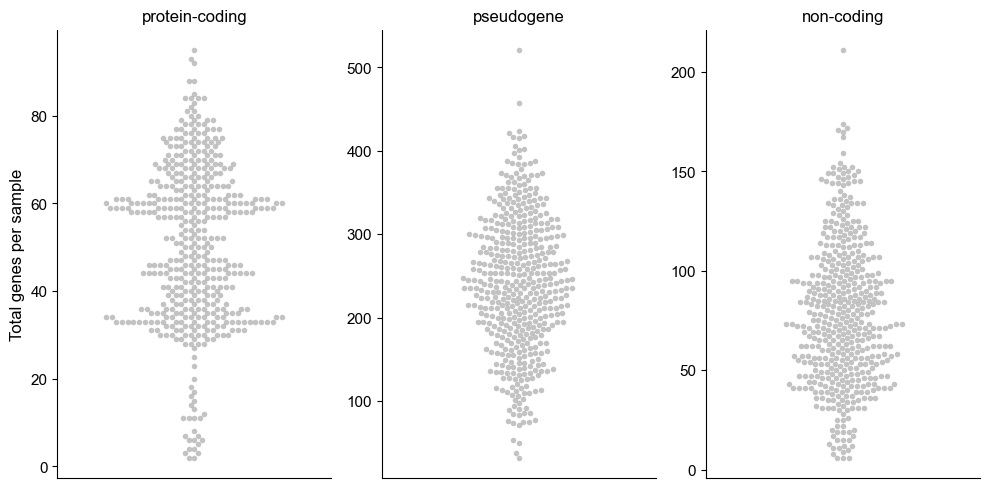

In [ ]:
import seaborn as sns

# total genes per (sample, haplotype, biotype_class) summed across all chroms
per_sample = (
    genes_df
    .groupby(["sample_id", "haplotype", "biotype_class"])
    .size()
    .reset_index(name="count")
)

# ensure all three categories present for every sample (fill missing with 0)
from itertools import product
all_samples = genes_df[["sample_id", "haplotype"]].drop_duplicates()
full_index = pd.DataFrame(
    [(row.sample_id, row.haplotype, b)
     for row in all_samples.itertuples()
     for b in ["protein-coding", "pseudogene", "non-coding"]],
    columns=["sample_id", "haplotype", "biotype_class"]
)
per_sample = full_index.merge(per_sample, on=["sample_id", "haplotype", "biotype_class"], how="left").fillna(0)

order = ["protein-coding", "pseudogene", "non-coding"]
HIGHLIGHT = "CHM13"

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, biotype in zip(axes, order):
    data = per_sample[per_sample["biotype_class"] == biotype]
    non_hl = data[data["sample_id"] != HIGHLIGHT]
    hl     = data[data["sample_id"] == HIGHLIGHT]

    sns.swarmplot(data=non_hl, y="count", color="#aaaaaa", size=4, alpha=0.7, ax=ax)
    if not hl.empty:
        sns.swarmplot(data=hl, y="count", color="#e63946", size=6, ax=ax)

    ax.set_title(biotype, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Total genes per sample" if ax == axes[0] else "", fontsize=12)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=11)

plt.tight_layout()

plt.show()




/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 28.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


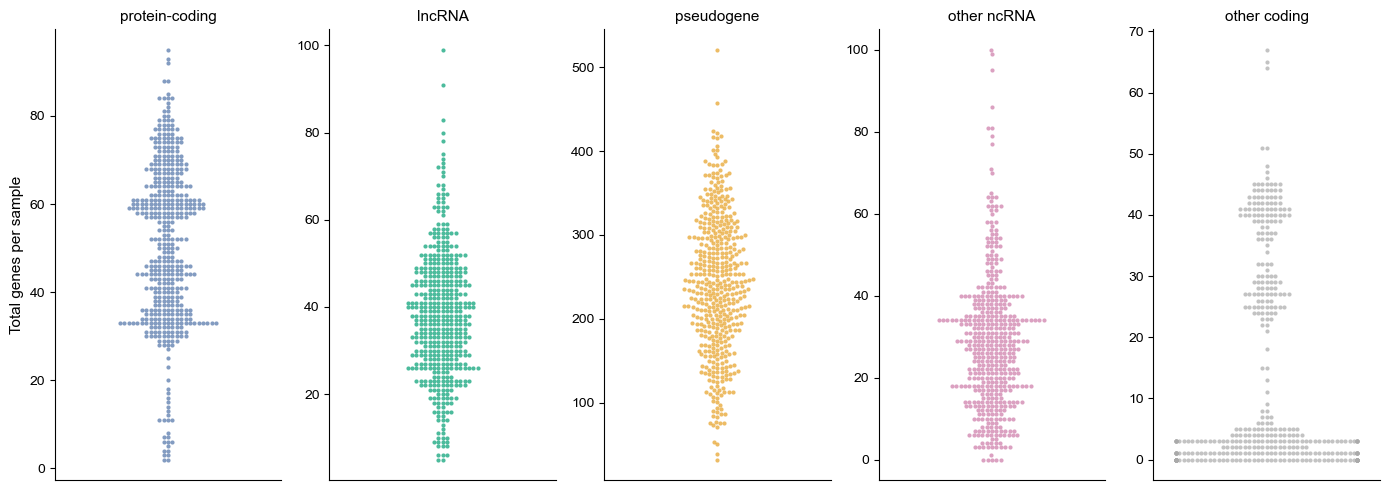

In [ ]:
def classify_biotype_5(b):
    if b == "protein_coding":
        return "protein-coding"
    elif b == "lncRNA":
        return "lncRNA"
    elif "pseudogene" in b:
        return "pseudogene"
    elif b in ("snRNA", "snoRNA", "miRNA", "rRNA", "misc_RNA"):
        return "other ncRNA"
    else:
        return "other coding"

genes_df["biotype_class5"] = genes_df["gene_biotype"].apply(classify_biotype_5)

order5 = ["protein-coding", "lncRNA", "pseudogene", "other ncRNA", "other coding"]
colors5 = ["#4E72A7", "#009E73", "#E6A024", "#CC79A7", "#aaaaaa"]

per_sample5 = (
    genes_df
    .groupby(["sample_id", "haplotype", "biotype_class5"])
    .size()
    .reset_index(name="count")
)

full_index5 = pd.DataFrame(
    [(row.sample_id, row.haplotype, b)
     for row in genes_df[["sample_id","haplotype"]].drop_duplicates().itertuples()
     for b in order5],
    columns=["sample_id", "haplotype", "biotype_class5"]
)
per_sample5 = full_index5.merge(per_sample5, on=["sample_id","haplotype","biotype_class5"], how="left").fillna(0)

HIGHLIGHT = "CHM13"
fig, axes = plt.subplots(1, 5, figsize=(14, 5))

for ax, biotype, color in zip(axes, order5, colors5):
    data   = per_sample5[per_sample5["biotype_class5"] == biotype]
    non_hl = data[data["sample_id"] != HIGHLIGHT]
    hl     = data[data["sample_id"] == HIGHLIGHT]

    sns.swarmplot(data=non_hl, y="count", color=color, size=3, alpha=0.7, ax=ax)
    if not hl.empty:
        sns.swarmplot(data=hl, y="count", color="#e63946", size=6, ax=ax)

    ax.set_title(biotype, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Total genes per sample" if ax == axes[0] else "", fontsize=11)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()


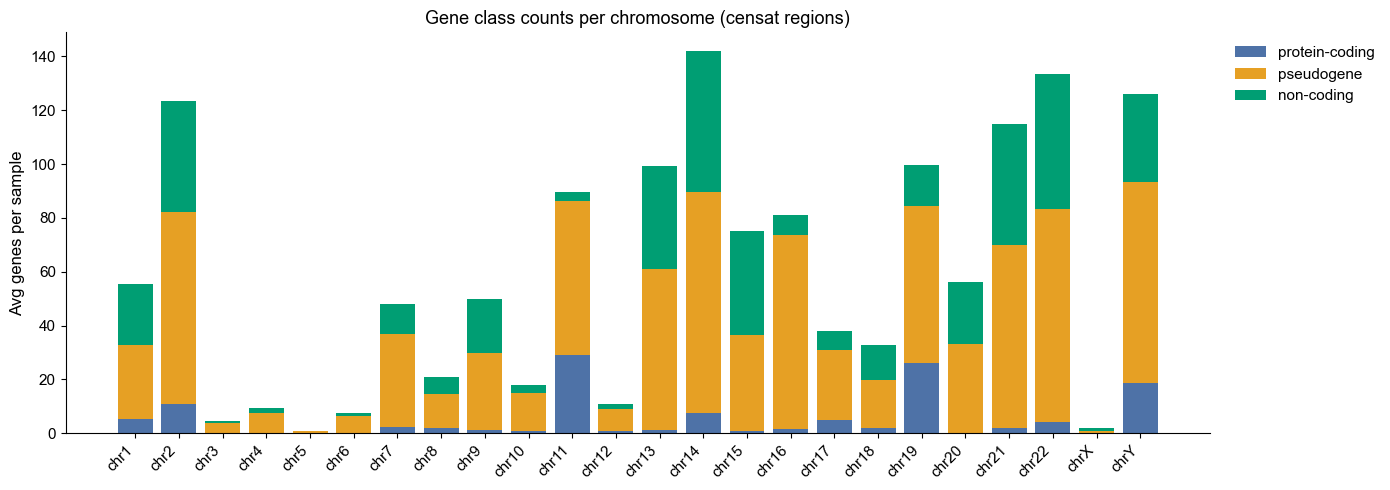

In [ ]:
def classify_biotype(b):
    if b == "protein_coding":
        return "protein-coding"
    elif "pseudogene" in b:
        return "pseudogene"
    else:
        return "non-coding"

genes_df["biotype_class"] = genes_df["gene_biotype"].apply(classify_biotype)

# average count per sample per chrom per biotype class
per_sample_chrom = (
    genes_df
    .groupby(["sample_id", "haplotype", "chrom", "biotype_class"])
    .size()
    .reset_index(name="count")
)

biotype_counts = (
    per_sample_chrom
    .groupby(["chrom", "biotype_class"])["count"]
    .mean()
    .unstack(fill_value=0)
)

def chrom_sort_key(c):
    c = c.replace("chr", "")
    return (0, int(c)) if c.isdigit() else (1, c)

biotype_counts = biotype_counts.loc[
    sorted(biotype_counts.index, key=chrom_sort_key)
]

for col in ["protein-coding", "pseudogene", "non-coding"]:
    if col not in biotype_counts.columns:
        biotype_counts[col] = 0
biotype_counts = biotype_counts[["protein-coding", "pseudogene", "non-coding"]]

colors = ["#4E72A7", "#E6A024", "#009E73"]

fig, ax = plt.subplots(figsize=(14, 5))

bottom = np.zeros(len(biotype_counts))
for j, col in enumerate(biotype_counts.columns):
    vals = biotype_counts[col].values
    ax.bar(range(len(biotype_counts)), vals, bottom=bottom,
           label=col, color=colors[j], width=0.8)
    bottom += vals

ax.set_xticks(range(len(biotype_counts)))
ax.set_xticklabels(biotype_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Avg genes per sample", fontsize=12)
ax.set_title("Gene class counts per chromosome (censat regions)", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.legend(frameon=False, fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()

plt.show()


301 genes pass filter, showing top 50 most variable
             median      cn_ratio
count  91947.000000  91947.000000
mean       1.099459      1.019460
std        0.378917      0.189627
min        1.000000      0.250000
25%        1.000000      1.000000
50%        1.000000      1.000000
75%        1.000000      1.000000
max        4.000000      7.000000


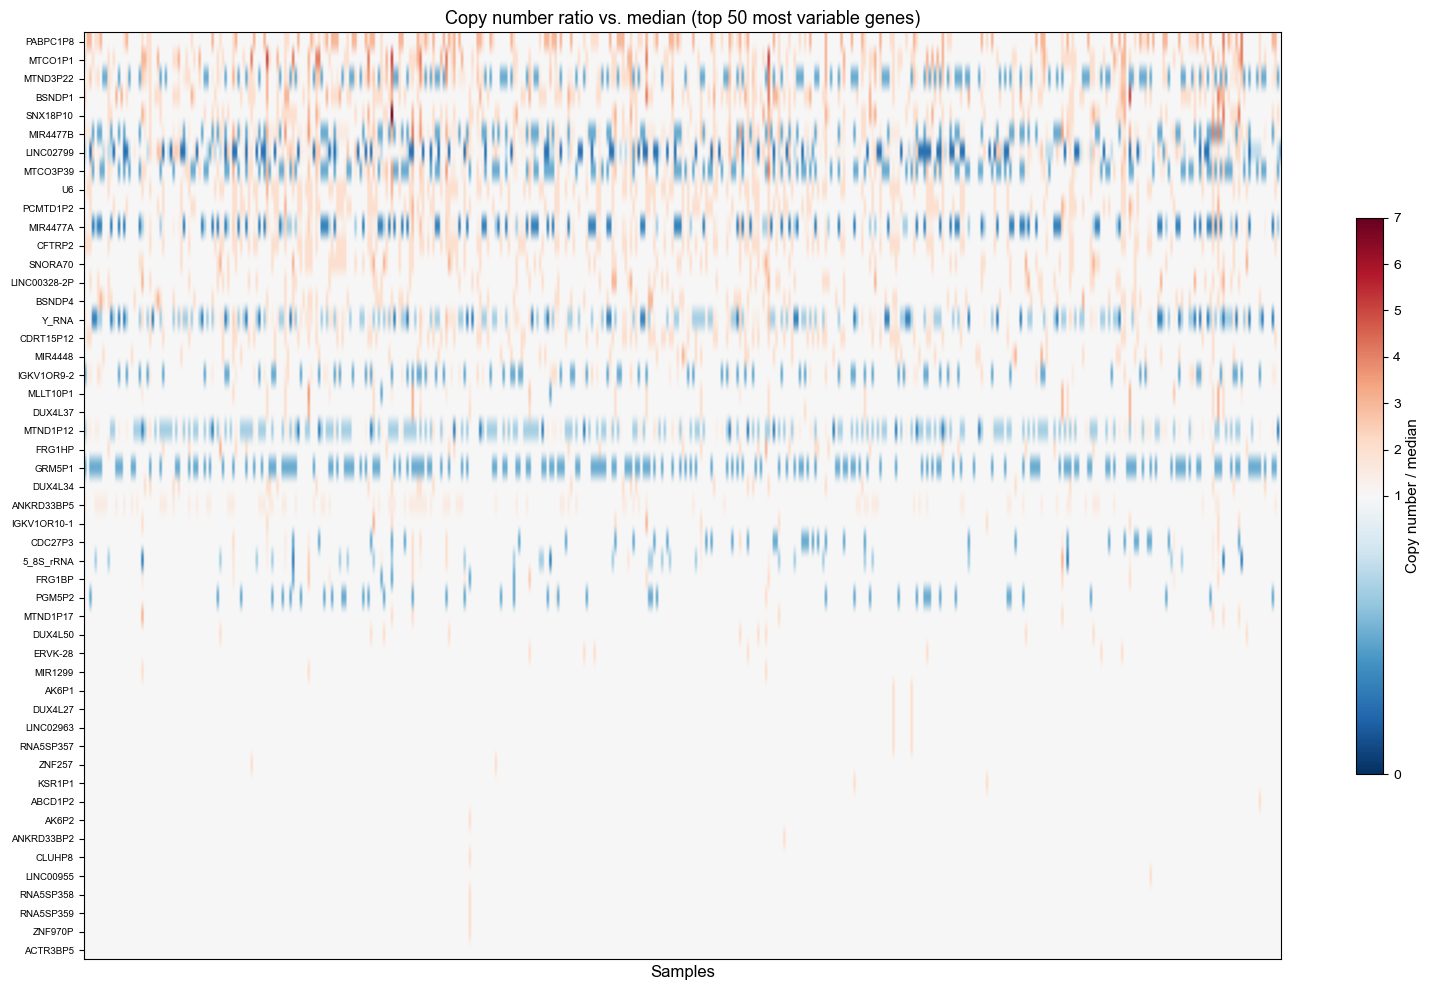

In [ ]:
# count copies of each gene per sample+haplotype (across all chroms)
copy_counts = (
    genes_df
    .groupby(["sample_id", "haplotype", "gene_name"])
    .size()
    .reset_index(name="copy_count")
)

# median copy count per gene across all samples
gene_medians = (
    copy_counts
    .groupby("gene_name")["copy_count"]
    .agg(median="median", n_samples="count")
    .reset_index()
)

# keep genes observed in at least half of samples
min_samples = genes_df[["sample_id", "haplotype"]].drop_duplicates().shape[0] * 0.5
gene_medians = gene_medians[gene_medians["n_samples"] >= min_samples]

copy_counts = copy_counts[copy_counts["gene_name"].isin(gene_medians["gene_name"])]

# merge median in and compute ratio
copy_counts = copy_counts.merge(gene_medians[["gene_name", "median"]], on="gene_name")
copy_counts["cn_ratio"] = copy_counts["copy_count"] / copy_counts["median"]

# pivot to heatmap: genes x samples
copy_counts["sample_hap"] = copy_counts["sample_id"] + "." + copy_counts["haplotype"]
cn_matrix = copy_counts.pivot_table(
    index="gene_name", columns="sample_hap", values="cn_ratio", fill_value=1.0
)

# keep only genes with high variance across samples
gene_var = cn_matrix.var(axis=1)
top_variable = gene_var.nlargest(50).index
cn_matrix_top = cn_matrix.loc[top_variable]

print(f"{len(gene_medians)} genes pass filter, showing top 10 most variable")
print(copy_counts[["gene_name", "median", "cn_ratio"]].describe())

# heatmap
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(16, 10))
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=cn_matrix_top.values.max())

im = ax.imshow(cn_matrix_top.values, aspect="auto", cmap=cmap, norm=norm)

ax.set_yticks(range(len(cn_matrix_top)))
ax.set_yticklabels(cn_matrix_top.index, fontsize=7)
ax.set_xticks([])
ax.set_xlabel("Samples", fontsize=12)
ax.set_title("Copy number ratio vs. median (top 10 most variable genes)", fontsize=13)

cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("Copy number / median", fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


/data/tmp/ipykernel_1533076/3428498688.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top10, rotation=45, ha='right', fontsize=11)


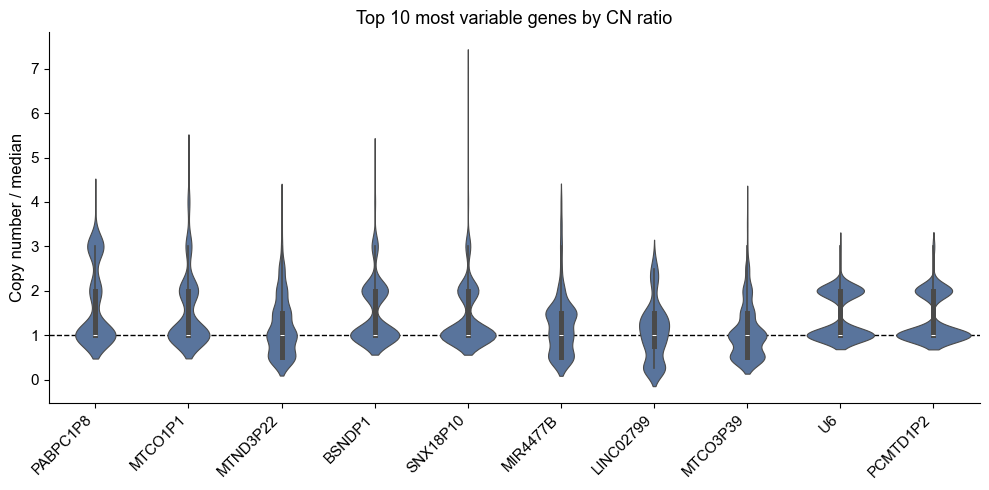

In [ ]:
top10 = gene_var.nlargest(10).index

plot_data = copy_counts[copy_counts["gene_name"].isin(top10)]

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(data=plot_data, x="gene_name", y="cn_ratio",
               order=top10, color="#4E72A7", ax=ax,
               inner="box", linewidth=0.8)

ax.axhline(1.0, color="black", linewidth=1, linestyle="--", zorder=0)
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Copy number / median", fontsize=12)
ax.set_title("Top 10 most variable genes by CN ratio", fontsize=13)
ax.set_xticklabels(top10, rotation=45, ha='right', fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()

plt.show()


In [ ]:
import os
import glob
import pandas as pd

censat_results_dir = "/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/annotate_gff3_with_censat/results"

censat_cols = ["seqname", "start", "end", "strand", "chrom", "attributes",
               "censat_annot", "censat_category"]

records = []
for fpath in glob.glob(os.path.join(censat_results_dir, "*.genes.censat.tsv")):
    basename = os.path.basename(fpath)
    sample_id, haplotype = basename.split(".")[:2]

    df = pd.read_csv(fpath, sep="\t", header=None, names=censat_cols, low_memory=False)
    if df.empty:
        continue

    df["sample_id"]  = sample_id
    df["haplotype"]  = haplotype

    # parse gene_name and biotype from attributes
    def get_attr(attr_str, key):
        for field in str(attr_str).split(";"):
            if field.startswith(key + "="):
                return field.split("=", 1)[1]
        return ""

    df["gene_name"]    = df["attributes"].apply(lambda x: get_attr(x, "source_gene_common_name") or get_attr(x, "gene_name") or get_attr(x, "Name"))
    df["gene_biotype"] = df["attributes"].apply(lambda x: get_attr(x, "gene_biotype"))

    records.append(df)

censat_genes_df = pd.concat(records, ignore_index=True)
censat_genes_df = censat_genes_df.drop(columns=["attributes"])

print(f"{len(censat_genes_df):,} records across {censat_genes_df['sample_id'].nunique()} samples")
print(censat_genes_df["censat_category"].value_counts())
censat_genes_df.head()


213,490 records across 231 samples
censat_category
CT             170495
bSat            11560
rDNA             5935
SST1             5494
mon              5339
HSAT5            4183
HSAT4            2849
dhor             1774
SATR             1156
CER              1146
HSAT2            1116
HSAT3             746
gSat              716
hor               422
mixedAlpha        233
active_hor        185
HSAT1              73
acrocentric        44
GAP                22
other               2
Name: count, dtype: int64


,seqname,start,end,strand,chrom,censat_annot,censat_category,sample_id,haplotype,gene_name,gene_biotype
0,CM086634.1,89369425,90430788,.,chr2,HSat3,HSAT3,HG03927,1,IGKV1-39,IG_V_gene
1,CM086634.1,89369425,90430788,.,chr2,HSat2,HSAT2,HG03927,1,IGKV1-39,IG_V_gene
2,CM086634.1,89369425,90430788,.,chr2,HSat2,HSAT2,HG03927,1,IGKV1-39,IG_V_gene
3,CM086634.1,89369425,90430788,.,chr2,HSat2,HSAT2,HG03927,1,IGKV1-39,IG_V_gene
4,CM086634.1,89369425,90430788,.,chr2,HSat3,HSAT3,HG03927,1,IGKV1-39,IG_V_gene


In [ ]:
## Select category with largest overlap 

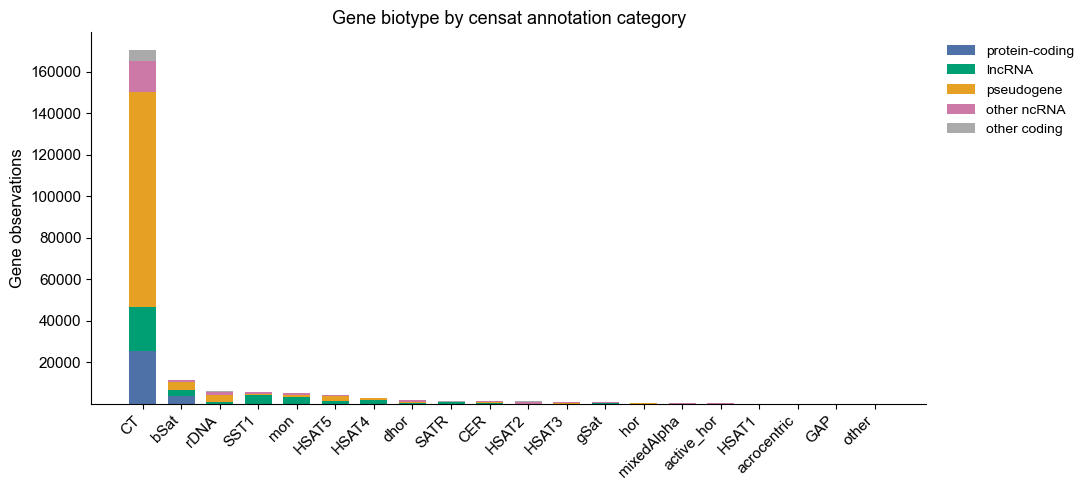

In [ ]:
# classify biotypes in censat_genes_df
censat_genes_df["biotype_class5"] = censat_genes_df["gene_biotype"].apply(classify_biotype_5)

order5      = ["protein-coding", "lncRNA", "pseudogene", "other ncRNA", "other coding"]
colors5     = ["#4E72A7", "#009E73", "#E6A024", "#CC79A7", "#aaaaaa"]

# count per (censat_category, biotype_class5)
cat_counts = (
    censat_genes_df
    .groupby(["censat_category", "biotype_class5"])
    .size()
    .unstack(fill_value=0)
)

# ensure all 5 biotype columns present
for col in order5:
    if col not in cat_counts.columns:
        cat_counts[col] = 0
cat_counts = cat_counts[order5]

# order censat categories by total count
cat_counts = cat_counts.loc[cat_counts.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))

bottom = np.zeros(len(cat_counts))
for col, color in zip(order5, colors5):
    vals = cat_counts[col].values
    ax.bar(range(len(cat_counts)), vals, bottom=bottom,
           label=col, color=color, width=0.7)
    bottom += vals

ax.set_xticks(range(len(cat_counts)))
ax.set_xticklabels(cat_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Gene observations", fontsize=12)
ax.set_title("Gene biotype by censat annotation category", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.legend(frameon=False, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig("/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/biotype_by_censat_category.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
censat_genes_df[censat_genes_df["censat_category"] == "other"]["censat_annot"].value_counts()


censat_annot
cenSat(COMP-subunit_FAM90A_rnd-6_family-7382)    2
Name: count, dtype: int64

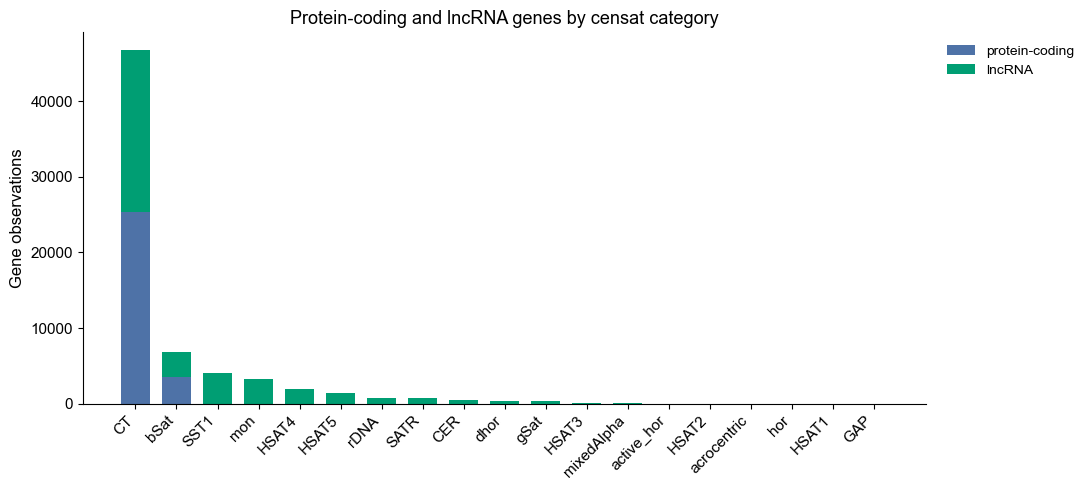

In [ ]:
censat_genes_df["biotype_class5"] = censat_genes_df["gene_biotype"].apply(classify_biotype_5)

order2  = ["protein-coding", "lncRNA"]
colors2 = ["#4E72A7", "#009E73"]

filt = censat_genes_df[censat_genes_df["biotype_class5"].isin(order2)]

cat_counts = (
    filt
    .groupby(["censat_category", "biotype_class5"])
    .size()
    .unstack(fill_value=0)
)

for col in order2:
    if col not in cat_counts.columns:
        cat_counts[col] = 0
cat_counts = cat_counts[order2]

cat_counts = cat_counts.loc[cat_counts.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))

bottom = np.zeros(len(cat_counts))
for col, color in zip(order2, colors2):
    vals = cat_counts[col].values
    ax.bar(range(len(cat_counts)), vals, bottom=bottom,
           label=col, color=color, width=0.7)
    bottom += vals

ax.set_xticks(range(len(cat_counts)))
ax.set_xticklabels(cat_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Gene observations", fontsize=12)
ax.set_title("Protein-coding and lncRNA genes by censat category", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.legend(frameon=False, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
censat_genes_df["biotype_class5"] = censat_genes_df["gene_biotype"].apply(classify_biotype_5)

order2 = ["protein-coding", "lncRNA"]

filt = censat_genes_df[censat_genes_df["biotype_class5"].isin(order2)]

cat_counts = (
    filt
    .groupby(["censat_category", "biotype_class5"])
    .size()
    .unstack(fill_value=0)
)

for col in order2:
    if col not in cat_counts.columns:
        cat_counts[col] = 0
cat_counts = cat_counts[order2]
cat_counts["total"] = cat_counts.sum(axis=1)
cat_counts = cat_counts.sort_values("total", ascending=False)

cat_counts


biotype_class5,protein-coding,lncRNA,total
censat_category,,,
CT,25367,21393,46760
bSat,3575,3276,6851
SST1,15,4105,4120
mon,27,3282,3309
HSAT4,3,1993,1996
HSAT5,1,1473,1474
rDNA,5,810,815
SATR,1,755,756
CER,0,516,516


/data/tmp/ipykernel_1533076/3236731903.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["biotype"] = plot_data["gene_name"].map(biotype_map)


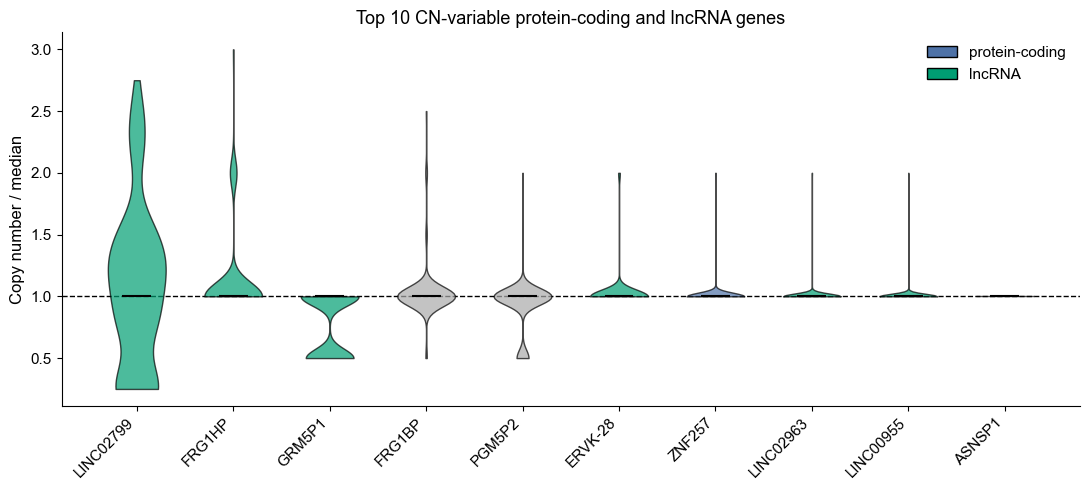

In [ ]:
# filter copy_counts to protein-coding and lncRNA only
coding_lnc_genes = genes_df[genes_df["biotype_class5"].isin(["protein-coding", "lncRNA"])]["gene_name"].unique()

coding_lnc_copy = copy_counts[copy_counts["gene_name"].isin(coding_lnc_genes)]

# top 10 most variable by CN ratio variance
coding_lnc_var = (
    coding_lnc_copy
    .groupby("gene_name")["cn_ratio"]
    .var()
    .dropna()
)
top10_coding = coding_lnc_var.nlargest(10).index

plot_data = coding_lnc_copy[coding_lnc_copy["gene_name"].isin(top10_coding)]

# label by biotype for color
biotype_map = (
    genes_df[["gene_name", "biotype_class5"]]
    .groupby("gene_name")["biotype_class5"]
    .agg(lambda x: x.mode()[0])
)
plot_data["biotype"] = plot_data["gene_name"].map(biotype_map)


color_map = {"protein-coding": "#4E72A7", "lncRNA": "#009E73"}

fig, ax = plt.subplots(figsize=(11, 5))

parts = ax.violinplot(
    [plot_data[plot_data["gene_name"] == g]["cn_ratio"].values for g in top10_coding],
    positions=range(len(top10_coding)),
    showmedians=True, showextrema=False, widths=0.6
)

for i, (pc, g) in enumerate(zip(parts["bodies"], top10_coding)):
    biotype = biotype_map.get(g, "other")
    pc.set_facecolor(color_map.get(biotype, "#aaaaaa"))
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.5)

ax.axhline(1.0, color="black", linewidth=1, linestyle="--", zorder=0)
ax.set_xticks(range(len(top10_coding)))
ax.set_xticklabels(top10_coding, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Copy number / median", fontsize=12)
ax.set_title("Top 10 CN-variable protein-coding and lncRNA genes", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize=11)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, edgecolor="black", label=l)
                   for l, c in color_map.items()],
          frameon=False, fontsize=11)

plt.tight_layout()

plt.show()


/data/tmp/ipykernel_1533076/3296916679.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_genes, rotation=45, ha="right", fontsize=11)


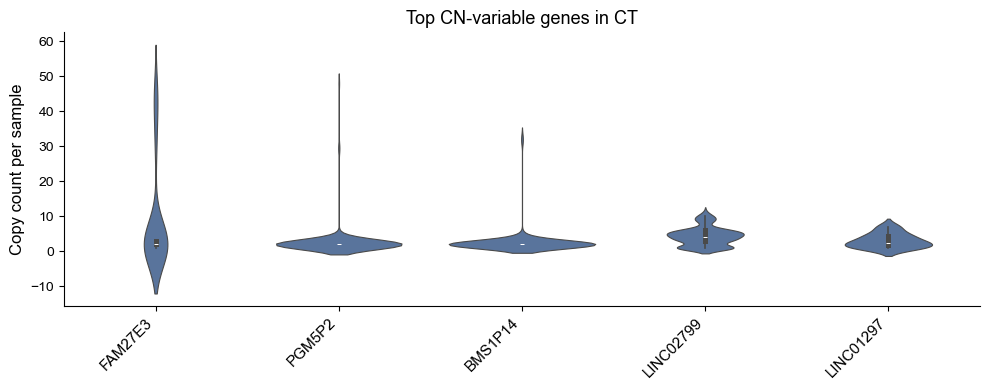

In [ ]:
# filter to protein-coding and lncRNA
coding_lnc_censat = censat_genes_df[
    censat_genes_df["biotype_class5"].isin(["protein-coding", "lncRNA"])
]

# count copies per gene per sample per censat category
cn_per_cat = (
    coding_lnc_censat
    .groupby(["censat_category", "gene_name", "sample_id", "haplotype"])
    .size()
    .reset_index(name="copy_count")
)

# median and sample count per (censat_category, gene_name)
gene_cat_stats = (
    cn_per_cat
    .groupby(["censat_category", "gene_name"])["copy_count"]
    .agg(median="median", n_samples="count", variance="var")
    .reset_index()
)

# require gene seen in at least 10 assemblies within that category
gene_cat_stats = gene_cat_stats[gene_cat_stats["n_samples"] >= 10]

# top 5 most variable per censat category
top_per_cat = (
    gene_cat_stats
    .sort_values("variance", ascending=False)
    .groupby("censat_category")
    .head(5)
    .sort_values(["censat_category", "variance"], ascending=[True, False])
)

top_per_cat[["censat_category", "gene_name", "median", "variance", "n_samples"]]
cat = "CT"  # change to any censat_category

top_genes = top_per_cat[top_per_cat["censat_category"] == cat]["gene_name"].tolist()
plot_data = cn_per_cat[
    (cn_per_cat["censat_category"] == cat) &
    (cn_per_cat["gene_name"].isin(top_genes))
]

fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=plot_data, x="gene_name", y="copy_count",
               order=top_genes, color="#4E72A7", inner="box", linewidth=0.8, ax=ax)
ax.set_title(f"Top CN-variable genes in {cat}", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Copy count per sample", fontsize=12)
ax.set_xticklabels(top_genes, rotation=45, ha="right", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



In [ ]:
cat = "CT"

# get most common chrom per gene within CT
gene_chrom = (
    coding_lnc_censat[coding_lnc_censat["censat_category"] == cat]
    .groupby("gene_name")["chrom"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

top_genes_ct = (
    top_per_cat[top_per_cat["censat_category"] == cat]
    .merge(gene_chrom, on="gene_name", how="left")
    .sort_values("variance", ascending=False)
)

display(top_genes_ct[["gene_name", "chrom", "median", "variance", "n_samples"]])

top_genes = top_genes_ct["gene_name"].tolist()
gene_to_chrom = top_genes_ct.set_index("gene_name")["chrom"].to_dict()

plot_data = cn_per_cat[
    (cn_per_cat["censat_category"] == cat) &
    (cn_per_cat["gene_name"].isin(top_genes))
]

fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=plot_data, x="gene_name", y="copy_count",
               order=top_genes, color="#4E72A7", inner="box", linewidth=0.8, ax=ax)
ax.set_title(f"Top CN-variable genes in {cat}", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Copy count per sample", fontsize=12)
xticklabels = [f"{g}\n({gene_to_chrom.get(g, '?')})" for g in top_genes]
ax.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


NameError: name 'coding_lnc_censat' is not defined

### Protein coding genes in CT regions conserved across all samples

In [ ]:
# filter to protein-coding genes in CT regions
ct_coding = censat_genes_df[
    (censat_genes_df["censat_category"] == "CT") &
    (censat_genes_df["biotype_class5"] == "protein-coding")
]

# total assemblies per chrom
total_per_chrom = (
    censat_genes_df
    .groupby("chrom")[["sample_id", "haplotype"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
    .rename("total_assemblies")
)

# count how many unique assemblies have each gene per chrom
gene_freq = (
    ct_coding
    .groupby(["chrom", "gene_name"])[["sample_id", "haplotype"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
    .reset_index(name="n_assemblies")
)

gene_freq = gene_freq.merge(total_per_chrom, on="chrom")
gene_freq["frequency"] = gene_freq["n_assemblies"] / gene_freq["total_assemblies"]

# genes present in >= 80% of assemblies for their chromosome
conserved_ct = (
    gene_freq[gene_freq["frequency"] >= 0.8]
    .sort_values(["chrom", "frequency"], ascending=[True, False])
)

conserved_ct


,chrom,gene_name,n_assemblies,total_assemblies,frequency
4,chr1,NBPF15,91,95,0.957895
6,chr1,PPIAL4F,91,95,0.957895
5,chr1,PPIAL4E,89,95,0.936842
3,chr1,H3-7,78,95,0.821053
0,chr1,FAM72C,76,95,0.800000
...,...,...,...,...,...
133,chr22,POTEH,3,3,1.000000
139,chr7,ZNF479,252,252,1.000000
142,chr7,ZNF716,252,252,1.000000
150,chr8,POTEA,320,320,1.000000


In [ ]:
# count distinct censat categories per gene per assembly
multi_cat = (
    censat_genes_df
    .groupby(["sample_id", "haplotype", "seqname", "start", "end", "gene_name"])["censat_category"]
    .nunique()
    .reset_index(name="n_categories")
)

# genes with more than one censat category
spanning = multi_cat[multi_cat["n_categories"] > 1]

print(f"{spanning['gene_name'].nunique()} unique genes span multiple censat categories")
spanning.sort_values("n_categories", ascending=False)


150 unique genes span multiple censat categories


,sample_id,haplotype,seqname,start,end,gene_name,n_categories
156041,NA19909,2,CM094132.1,120961857,138575185,LINC01145,17
118826,HG03834,1,CM085799.1,40753408,71874514,MIR4477B,15
139844,NA18967,1,JBKABW010000016.1,25061874,53334256,ORC6,15
132276,NA18747,1,CM087204.1,39844314,60002426,FGF7P8,14
55250,HG01981,1,JBHDRV010000002.1,39838916,67436194,FGF7P3,14
...,...,...,...,...,...,...,...
170492,NA21309,2,JAHEPB020000002.1,43472156,43536503,ZNF33B,2
170509,NA21309,2,JAHEPB020000037.1,14443926,14463784,LINC00664,2
557,HG00099,1,CM087323.1,37769343,37772051,TTTY7,2
239,HG00097,2,CM094086.1,25843600,25958530,FAM182A,2


In [ ]:
# get the actual category combinations per gene
cat_combos = (
    censat_genes_df
    .groupby(["gene_name", "chrom"])["censat_category"]
    .apply(lambda x: " | ".join(sorted(x.unique())))
    .reset_index(name="censat_categories")
)

spanning_detail = cat_combos[cat_combos["censat_categories"].str.contains(r"\|")]
spanning_detail["n_categories"] = spanning_detail["censat_categories"].str.count(r"\|") + 1
spanning_detail.sort_values("n_categories", ascending=False)


/data/tmp/ipykernel_1533076/2957830072.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spanning_detail["n_categories"] = spanning_detail["censat_categories"].str.count(r"\|") + 1


,gene_name,chrom,censat_categories,n_categories
705,LINC01145,chr1,CER | CT | GAP | HSAT2 | HSAT3 | HSAT5 | SATR ...,17
836,MIR4477B,chr9,CER | CT | GAP | HSAT2 | HSAT3 | HSAT5 | SATR ...,15
1161,ORC6,chr16,CT | GAP | HSAT2 | HSAT3 | HSAT4 | HSAT5 | SAT...,15
395,FAM27B,chr9,CER | CT | HSAT2 | HSAT3 | HSAT5 | SATR | SST1...,14
417,FGF7P3,chr9,CER | CT | HSAT2 | HSAT3 | HSAT5 | SATR | SST1...,14
...,...,...,...,...
1766,ZNF679,chr7,CT | bSat,2
1783,ZNF730,chr19,CT | bSat,2
1793,ZNF738,chr19,CT | bSat,2
1798,ZNF85,chr19,CT | bSat,2


In [ ]:
single_cat = multi_cat[multi_cat["n_categories"] == 1]
print(f"{single_cat['gene_name'].nunique()} unique genes overlap exactly one censat category")

# breakdown by category
(
    censat_genes_df
    .merge(single_cat[["sample_id", "haplotype", "seqname", "start", "end", "gene_name"]],
           on=["sample_id", "haplotype", "seqname", "start", "end", "gene_name"])
    .groupby("censat_category")["gene_name"]
    .nunique()
    .sort_values(ascending=False)
)


1217 unique genes overlap exactly one censat category


censat_category
CT             1133
rDNA             37
bSat             29
SST1             17
HSAT5            10
mon               8
HSAT4             3
hor               2
HSAT3             1
CER               1
HSAT1             1
SATR              1
acrocentric       1
active_hor        1
mixedAlpha        1
Name: gene_name, dtype: int64

### chr 1

7 variable genes on chr1


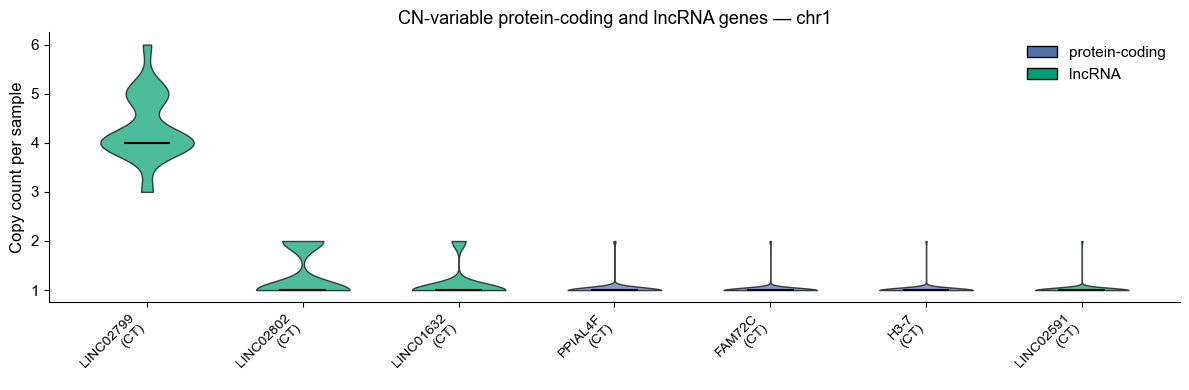

In [ ]:
chr1_coding_lnc = censat_genes_df[
    (censat_genes_df["chrom"] == "chr1") &
    (censat_genes_df["biotype_class5"].isin(["protein-coding", "lncRNA"]))
]

# count copies per gene per sample
chr1_cn = (
    chr1_coding_lnc
    .groupby(["gene_name", "sample_id", "haplotype", "biotype_class5", "censat_category"])
    .size()
    .reset_index(name="copy_count")
)

# median and variance per gene
chr1_stats = (
    chr1_cn
    .groupby(["gene_name", "biotype_class5", "censat_category"])["copy_count"]
    .agg(median="median", variance="var", n_samples="count")
    .reset_index()
)

# require seen in at least 10 assemblies, has any variance
chr1_variable = (
    chr1_stats[
        (chr1_stats["n_samples"] >= 10) &
        (chr1_stats["variance"] > 0)
    ]
    .sort_values("variance", ascending=False)
)

print(f"{len(chr1_variable)} variable genes on chr1")
chr1_variable.head(20)

top_genes_chr1 = chr1_variable["gene_name"].head(10).tolist()
plot_data = chr1_cn[chr1_cn["gene_name"].isin(top_genes_chr1)]

biotype_map2 = chr1_variable.set_index("gene_name")["biotype_class5"]
color_map = {"protein-coding": "#4E72A7", "lncRNA": "#009E73"}

fig, ax = plt.subplots(figsize=(12, 4))

parts = ax.violinplot(
    [plot_data[plot_data["gene_name"] == g]["copy_count"].values for g in top_genes_chr1],
    positions=range(len(top_genes_chr1)),
    showmedians=True, showextrema=False, widths=0.6
)
for pc, g in zip(parts["bodies"], top_genes_chr1):
    pc.set_facecolor(color_map.get(biotype_map2.get(g, ""), "#aaaaaa"))
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.5)

# annotate censat category below gene name
xlabels = [f"{g}\n({chr1_variable.set_index('gene_name').loc[g,'censat_category']})"
           for g in top_genes_chr1]

ax.set_xticks(range(len(top_genes_chr1)))
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=10)
ax.set_ylabel("Copy count per sample", fontsize=12)
ax.set_title("CN-variable protein-coding and lncRNA genes — chr1", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize=11)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, edgecolor="black", label=l)
                   for l, c in color_map.items()],
          frameon=False, fontsize=11)

plt.tight_layout()

plt.show()



In [ ]:
samples_of_interest = [
    ("HG03669", "1"),
    ("HG01361", "2"),
    ("HG01081", "2"),
    ("HG00639", "2"),
]

sample_ids = [s[0] for s in samples_of_interest]
haplotypes = [s[1] for s in samples_of_interest]

subset = chr1_cn[
    chr1_cn["gene_name"].isin(top_genes_chr1) &
    chr1_cn["sample_id"].isin(sample_ids) &
    chr1_cn["haplotype"].isin(haplotypes)
]

# verify we have the right sample+hap combos
subset = subset[
    subset.apply(lambda r: (r["sample_id"], r["haplotype"]) in samples_of_interest, axis=1)
]

pivot = subset.pivot_table(
    index="gene_name",
    columns=["sample_id", "haplotype"],
    values="copy_count",
    fill_value=0
)

print(pivot.to_string())

soi_df = pd.DataFrame(samples_of_interest, columns=["sample_id", "haplotype"])

subset = chr1_cn[chr1_cn["gene_name"].isin(top_genes_chr1)].merge(
    soi_df, on=["sample_id", "haplotype"]
)

pivot = subset.pivot_table(
    index="gene_name",
    columns=["sample_id", "haplotype"],
    values="copy_count",
    fill_value=0
)

print(pivot.to_string())



sample_id HG01081
haplotype       2
gene_name        
FAM72C        1.0
H3-7          1.0
LINC01632     1.0
LINC02591     1.0
LINC02799     4.0
LINC02802     1.5
PPIAL4F       1.0
sample_id HG01081
haplotype       2
gene_name        
FAM72C        1.0
H3-7          1.0
LINC01632     1.0
LINC02591     1.0
LINC02799     4.0
LINC02802     1.5
PPIAL4F       1.0
